# Problem Statement 3 — Environmental Condition Classification Pipeline

**Course:** Machine Learning (BITS Pilani)
**Dataset:** Environmental Sensor Data — 13,200 samples, 10 features, 4-class target
**Objective:** Build a robust, production-quality multi-class classification pipeline for noisy environmental sensor data, classifying weather conditions: *Cloudy, Rainy, Snowy, Sunny*.

---

| Section | Description |
|---------|-------------|
| 1 | Data Understanding & Sanity Diagnostics |
| 2 | Exploratory Data Analysis |
| 3 | Robust Preprocessing Pipeline |
| 4 | Model Development & Hyperparameter Tuning |
| 5 | Model Evaluation & Comparison |
| 6 | Findings, Insights & Contribution Report |

---
## Section 1: Data Understanding & Sanity Diagnostics

**Objective:** Understand the raw dataset structure, identify data quality issues, and formulate hypotheses about how these issues may impact model performance.

### 1.1 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OrdinalEncoder, LabelEncoder
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, IsolationForest
)
from sklearn.base import clone
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

print("All libraries loaded successfully.")

All libraries loaded successfully.


### 1.2 Load Dataset

Load the Excel dataset and inspect raw structure before any transformation. We immediately detect the target column programmatically to avoid hard-coding.

In [3]:
df = pd.read_excel("PS 3.xlsx")

TARGET = [col for col in df.columns if "env_condition_label" in col.lower()][0]

print(f"Dataset shape   : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target column   : '{TARGET}'")
print(f"Target classes  : {sorted(df[TARGET].unique())}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape   : 13,200 rows x 11 columns
Target column   : 'env_condition_label (Target)'
Target classes  : ['Cloudy', 'Rainy', 'Snowy', 'Sunny']

First 5 rows:


,ambient_temp_c,rel_humidity_pct,wind_velocity_kmh,precip_intensity_pct,cloud_state,atm_pressure_hpa,uv_radiation_idx,annual_phase,visibility_range_km,terrain_category,env_condition_label (Target)
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET]

print("=" * 60)
print(f"NUMERIC  FEATURES ({len(num_cols)}): {num_cols}")
print(f"CATEGORICAL FEATURES ({len(cat_cols)}): {cat_cols}")
print(f"TARGET            : {TARGET}")
print("=" * 60)

NUMERIC  FEATURES (7): ['ambient_temp_c', 'rel_humidity_pct', 'wind_velocity_kmh', 'precip_intensity_pct', 'atm_pressure_hpa', 'uv_radiation_idx', 'visibility_range_km']
CATEGORICAL FEATURES (3): ['cloud_state', 'annual_phase', 'terrain_category']
TARGET            : env_condition_label (Target)


### 1.3 Schema, Datatypes & Statistics

Inspect column dtypes, non-null counts, descriptive statistics, and value diversity to understand feature cardinality and detect encoding/imputation requirements.

In [5]:
print("─── DataFrame Info ───")
df.info()

print("\n─── Descriptive Statistics ───")
display(df.describe(include='all').round(3))

print("\n─── Unique Value Counts & Sample Values ───")
uvc = pd.DataFrame({
    'Dtype': df.dtypes,
    'Unique Values': df.nunique(),
    'Missing': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Sample Values': [df[c].dropna().unique()[:4].tolist() for c in df.columns]
})
display(uvc)

─── DataFrame Info ───
<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ambient_temp_c                13200 non-null  int64  
 1   rel_humidity_pct              13200 non-null  int64  
 2   wind_velocity_kmh             13200 non-null  float64
 3   precip_intensity_pct          13200 non-null  int64  
 4   cloud_state                   13200 non-null  str    
 5   atm_pressure_hpa              13200 non-null  float64
 6   uv_radiation_idx              13200 non-null  int64  
 7   annual_phase                  13200 non-null  str    
 8   visibility_range_km           13200 non-null  float64
 9   terrain_category              13200 non-null  str    
 10  env_condition_label (Target)  13200 non-null  str    
dtypes: float64(3), int64(4), str(4)
memory usage: 1.1 MB

─── Descriptive Statistics ───


,ambient_temp_c,rel_humidity_pct,wind_velocity_kmh,precip_intensity_pct,cloud_state,atm_pressure_hpa,uv_radiation_idx,annual_phase,visibility_range_km,terrain_category,env_condition_label (Target)
count,13200.000,13200.000,13200.000,13200.000,13200,13200.000,13200.000,13200,13200.000,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.128,68.711,9.832,53.644,NaN,1005.828,4.006,NaN,5.463,NaN,NaN
std,17.386,20.194,6.909,31.947,NaN,37.200,3.857,NaN,3.371,NaN,NaN
min,-25.000,20.000,0.000,0.000,NaN,800.120,0.000,NaN,0.000,NaN,NaN
25%,4.000,57.000,5.000,19.000,NaN,994.800,1.000,NaN,3.000,NaN,NaN
50%,21.000,70.000,9.000,58.000,NaN,1007.650,3.000,NaN,5.000,NaN,NaN
75%,31.000,84.000,13.500,82.000,NaN,1016.772,7.000,NaN,7.500,NaN,NaN



─── Unique Value Counts & Sample Values ───


,Dtype,Unique Values,Missing,Missing %,Sample Values
ambient_temp_c,int64,126,0,0.0,"[14, 39, 30, 38]"
rel_humidity_pct,int64,90,0,0.0,"[73, 96, 64, 83]"
wind_velocity_kmh,float64,97,0,0.0,"[9.5, 8.5, 7.0, 1.5]"
precip_intensity_pct,int64,110,0,0.0,"[82, 71, 16, 66]"
cloud_state,str,4,0,0.0,"[partly cloudy, clear, overcast, cloudy]"
atm_pressure_hpa,float64,5456,0,0.0,"[1010.82, 1011.43, 1018.72, 1026.25]"
uv_radiation_idx,int64,15,0,0.0,"[2, 7, 5, 1]"
annual_phase,str,4,0,0.0,"[Winter, Spring, Summer, Autumn]"
visibility_range_km,float64,41,0,0.0,"[3.5, 10.0, 5.5, 1.0]"
terrain_category,str,3,0,0.0,"[inland, mountain, coastal]"


### 1.4 Physically Impossible Values & Suspicious Ranges

We scan each feature against domain-valid physical ranges. Violations indicate sensor faults, data entry errors, or systematic calibration drift.

| Feature | Valid Range | Violation Indicator |
|---------|-------------|---------------------|
| `rel_humidity_pct` | 0–100 | > 100 is thermodynamically impossible |
| `ambient_temp_c` | -60 to +60 | > 60°C or < -60°C is extreme/sensor fault |
| `wind_velocity_kmh` | ≥ 0 | Negative wind speed is physically meaningless |
| `uv_radiation_idx` | 0–14 | UV index > 14 is beyond global maximum |
| `visibility_range_km` | ≥ 0 | Negative visibility is impossible |
| `precip_intensity_pct` | 0–100 | > 100% is undefined |
| `atm_pressure_hpa` | 870–1085 | Outside this range = extreme storm or sensor error |

In [6]:
def detect_anomalies(dataframe):
    """Report physically impossible or out-of-range values per sensor field."""
    checks = {
        'rel_humidity_pct > 100':      dataframe['rel_humidity_pct'] > 100,
        'ambient_temp_c > 60':         dataframe['ambient_temp_c'] > 60,
        'ambient_temp_c < -60':        dataframe['ambient_temp_c'] < -60,
        'wind_velocity_kmh < 0':       dataframe['wind_velocity_kmh'] < 0,
        'uv_radiation_idx > 14':       dataframe['uv_radiation_idx'] > 14,
        'visibility_range_km < 0':     dataframe['visibility_range_km'] < 0,
        'atm_pressure_hpa > 1085':     dataframe['atm_pressure_hpa'] > 1085,
        'atm_pressure_hpa < 870':      dataframe['atm_pressure_hpa'] < 870,
        'precip_intensity_pct > 100':  dataframe['precip_intensity_pct'] > 100,
        'precip_intensity_pct < 0':    dataframe['precip_intensity_pct'] < 0,
    }
    total = 0
    for label, mask in checks.items():
        count = int(mask.sum())
        total += count
        status = "WARNING" if count > 0 else "OK"
        print(f"  [{status:7s}]  {label}: {count} violations")
    print(f"\n  Total anomalous records: {total}")
    return checks

print("─── Pre-Fix Anomaly Detection ───")
_ = detect_anomalies(df)

# Apply physics-based clipping
df['rel_humidity_pct']     = df['rel_humidity_pct'].clip(0, 100)
df['ambient_temp_c']       = df['ambient_temp_c'].clip(-60, 60)
df['wind_velocity_kmh']    = df['wind_velocity_kmh'].clip(0, None)
df['uv_radiation_idx']     = df['uv_radiation_idx'].clip(0, 14)
df['visibility_range_km']  = df['visibility_range_km'].clip(0, None)
df['precip_intensity_pct'] = df['precip_intensity_pct'].clip(0, 100)

print("\n─── Post-Fix Verification ───")
_ = detect_anomalies(df)

─── Pre-Fix Anomaly Detection ───
  [WARNING]  rel_humidity_pct > 100: 416 violations
  [WARNING]  ambient_temp_c > 60: 207 violations
  [OK     ]  ambient_temp_c < -60: 0 violations
  [OK     ]  wind_velocity_kmh < 0: 0 violations
  [OK     ]  uv_radiation_idx > 14: 0 violations
  [OK     ]  visibility_range_km < 0: 0 violations
  [WARNING]  atm_pressure_hpa > 1085: 354 violations
  [WARNING]  atm_pressure_hpa < 870: 210 violations
  [WARNING]  precip_intensity_pct > 100: 392 violations
  [OK     ]  precip_intensity_pct < 0: 0 violations

  Total anomalous records: 1579

─── Post-Fix Verification ───
  [OK     ]  rel_humidity_pct > 100: 0 violations
  [OK     ]  ambient_temp_c > 60: 0 violations
  [OK     ]  ambient_temp_c < -60: 0 violations
  [OK     ]  wind_velocity_kmh < 0: 0 violations
  [OK     ]  uv_radiation_idx > 14: 0 violations
  [OK     ]  visibility_range_km < 0: 0 violations
  [WARNING]  atm_pressure_hpa > 1085: 354 violations
  [WARNING]  atm_pressure_hpa < 870: 210 vio

### 1.5 Data Quality Hypotheses

**Hypothesis 1 — Sensor Drift Corrupts Feature Distributions**

Environmental sensors degrade over time, producing systematic drift in readings (e.g., humidity sensors reading 5–10% higher after calibration shift). The presence of humidity > 100% and temperature > 60°C is direct evidence. This introduces non-stationary noise that makes learned decision boundaries stale over time.
*ML Impact:* Linear models (Logistic Regression, SVM with linear kernel) and distance-based models (KNN) are most sensitive because they rely on absolute feature magnitudes. Ensemble methods are more robust due to averaging across many trees.

---

**Hypothesis 2 — Extreme Outliers Distort Scale-Sensitive Models**

The temperature range spans −25 to 109°C (after clipping: −25 to 60°C), humidity peaks at 109%, and atmospheric pressure reaches 1199 hPa — all indicating sporadic sensor failures. Even after clipping, the distribution tails remain heavy.
*ML Impact:* StandardScaler amplifies outlier influence via z-score normalization; RobustScaler (median/IQR-based) is required for KNN and SVM. Decision Trees and Random Forests are inherently robust since they use rank-based splits.

---

**Hypothesis 3 — Class Label Noise from Sensor Misclassification**

With 4 weather classes and potential label assignment errors (e.g., a sensor logging "Sunny" during overcast conditions due to lag), class boundaries between similar conditions (Cloudy vs Rainy, Snowy vs Cloudy) may be blurry or contain mislabelled samples.
*ML Impact:* Hard-margin classifiers (SVM with small C, Decision Trees with no pruning) will overfit noisy boundaries. Soft-margin SVMs and ensembles that smooth boundaries across many weak learners are more robust. F1-macro is more reliable than accuracy.

---

**Hypothesis 4 — Categorical Features Carry Hidden Ordinal Structure**

`annual_phase` (Winter → Spring → Summer → Fall) and `cloud_state` (clear → partly cloudy → overcast) imply ordered gradients — treating them as purely nominal with One-Hot Encoding discards this ordering information and inflates dimensionality.
*ML Impact:* OHE creates orthogonal binary features where a gradient exists; Ordinal Encoding preserves the severity scale. Tree-based models can exploit ordinal structure through split sequences; linear models benefit directly from the numeric gradient.

---
## Section 2: Exploratory Data Analysis

**Objective:** Understand feature distributions, class separability, inter-feature correlations, and non-linear relationships to guide preprocessing and model selection decisions.

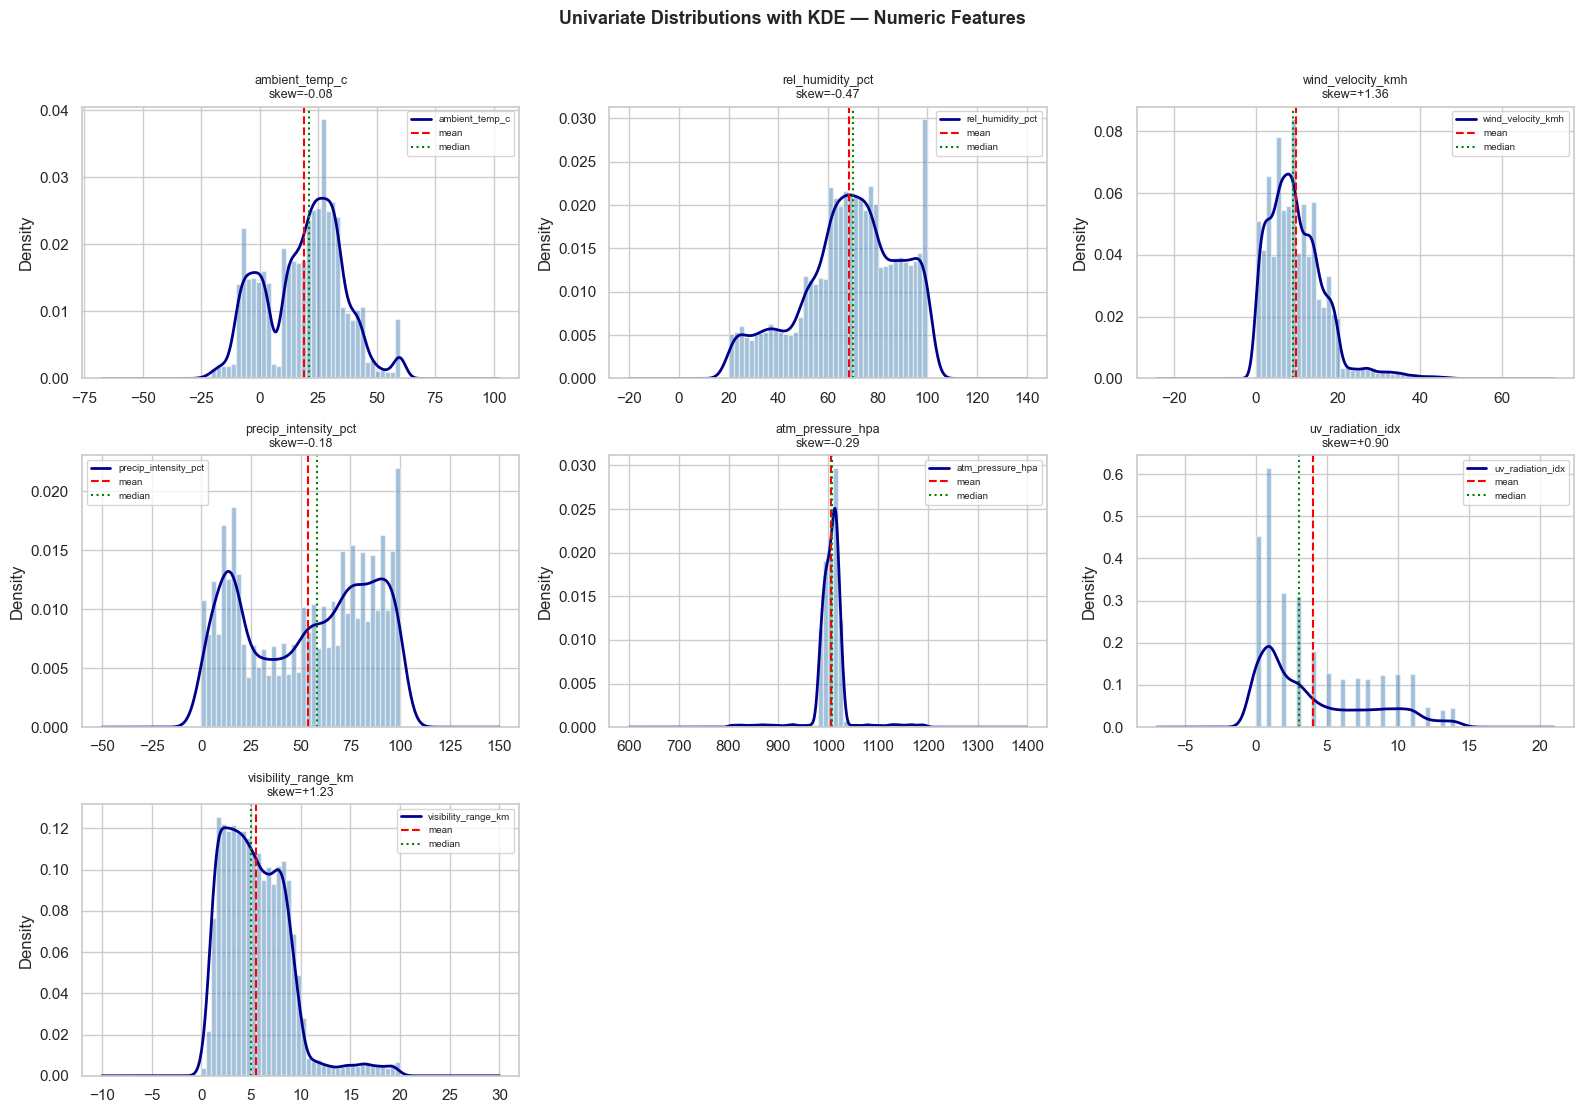


─── Skewness Summary ───
  wind_velocity_kmh                  : +1.360  [highly skewed]
  visibility_range_km                : +1.233  [highly skewed]
  uv_radiation_idx                   : +0.900  [moderately skewed]
  rel_humidity_pct                   : -0.468  [approximately normal]
  atm_pressure_hpa                   : -0.294  [approximately normal]
  precip_intensity_pct               : -0.176  [approximately normal]
  ambient_temp_c                     : -0.081  [approximately normal]


In [7]:
### 2.1 Univariate Analysis — Histograms, KDE & Skewness

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
axes = axes.flatten()

skewness_results = {}
for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    skew = float(data.skew())
    skewness_results[col] = skew
    ax.hist(data, bins=40, density=True, alpha=0.5, color='steelblue', edgecolor='white')
    data.plot.kde(ax=ax, color='darkblue', lw=2)
    ax.axvline(data.mean(),   color='red',    lw=1.5, linestyle='--', label='mean')
    ax.axvline(data.median(), color='green',  lw=1.5, linestyle=':',  label='median')
    ax.set_title(f"{col}\nskew={skew:+.2f}", fontsize=9)
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Univariate Distributions with KDE — Numeric Features", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n─── Skewness Summary ───")
skew_series = pd.Series(skewness_results).sort_values(key=abs, ascending=False)
for col, skew in skew_series.items():
    tag = ("highly skewed" if abs(skew) > 1.0
           else ("moderately skewed" if abs(skew) > 0.5 else "approximately normal"))
    print(f"  {col:35s}: {skew:+.3f}  [{tag}]")

### 2.2 Bivariate Analysis — Feature vs Target

Box plots reveal how each numeric feature distributes across the 4 weather classes. Well-separated median lines indicate strong discriminative power. Overlapping distributions suggest the model must combine multiple features.

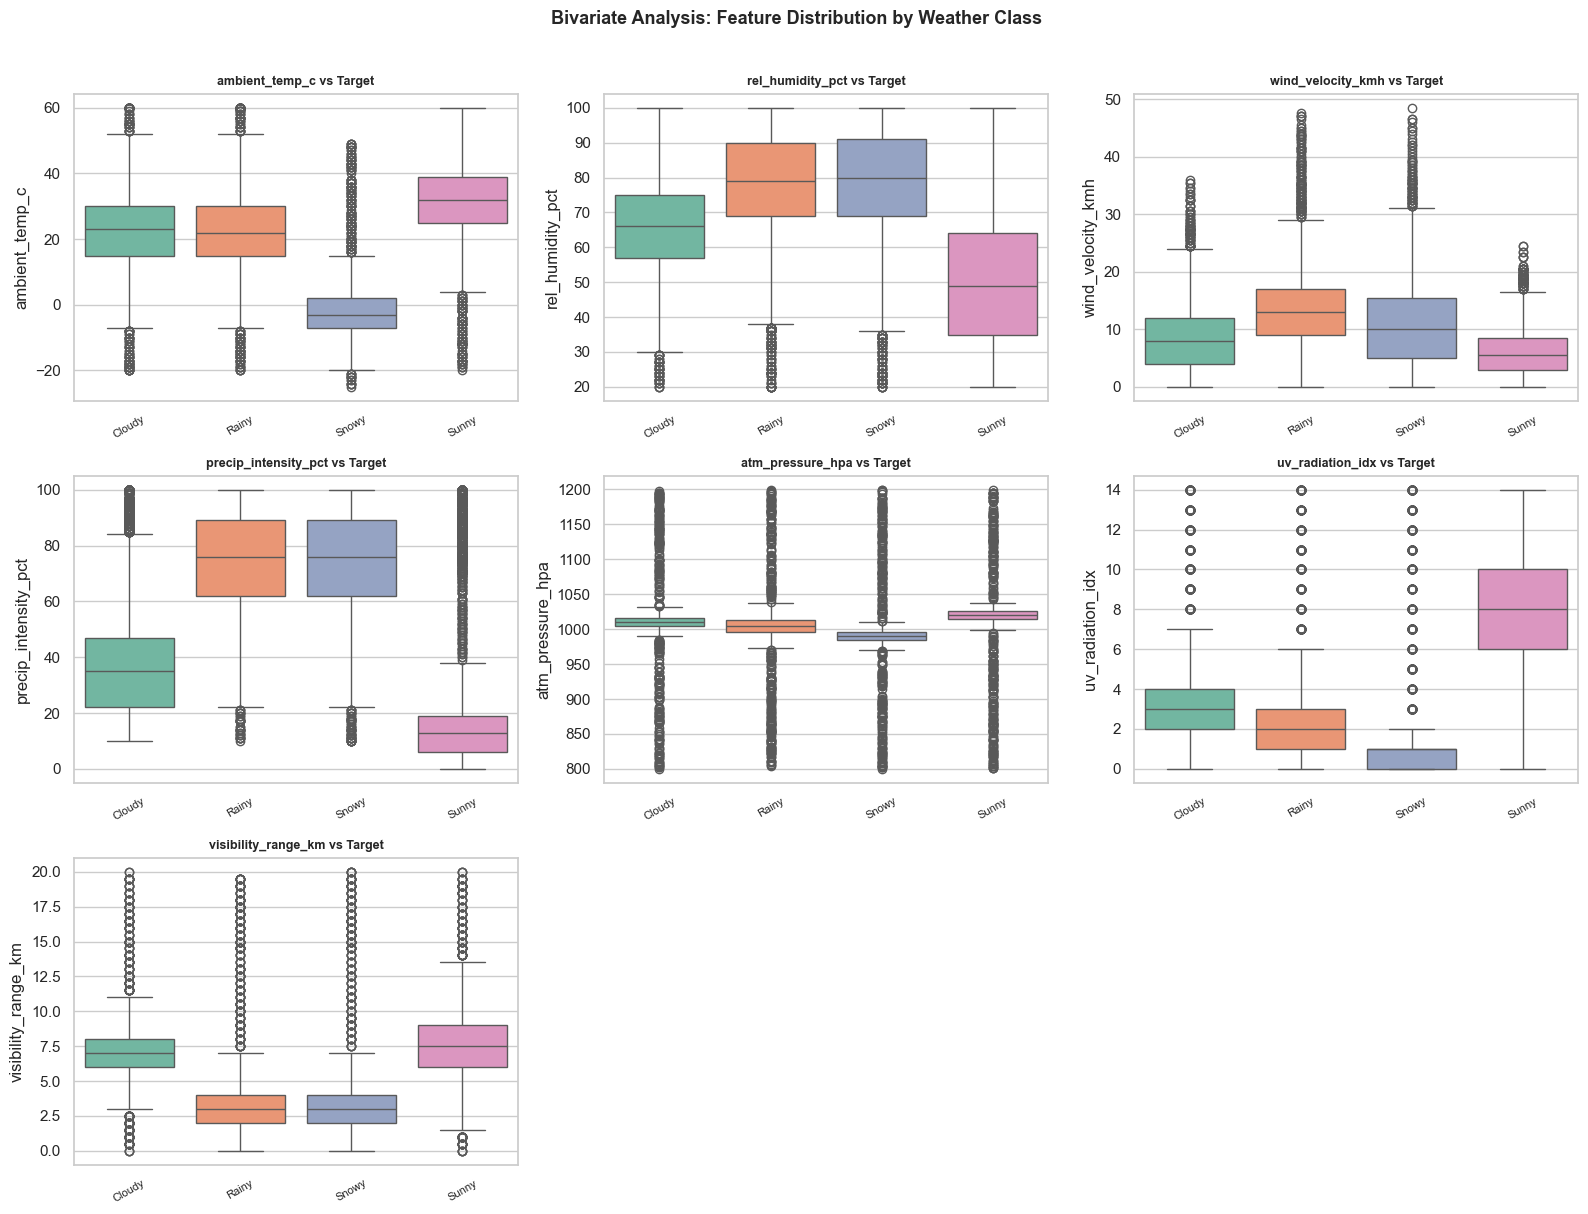

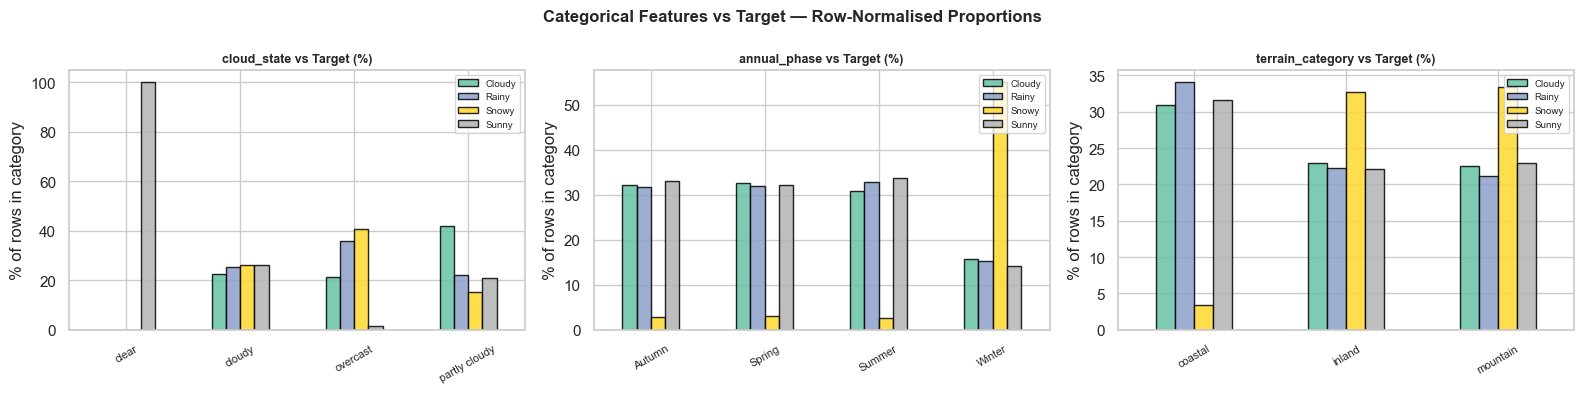

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
order = sorted(df[TARGET].unique())

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df, x=TARGET, y=col, order=order, ax=ax, palette='Set2')
    ax.set_title(f"{col} vs Target", fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Bivariate Analysis: Feature Distribution by Weather Class", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Categorical features vs target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black', alpha=0.85)
    axes[i].set_title(f"{col} vs Target (%)", fontweight='bold', fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].set_ylabel("% of rows in category")

plt.suptitle("Categorical Features vs Target — Row-Normalised Proportions", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

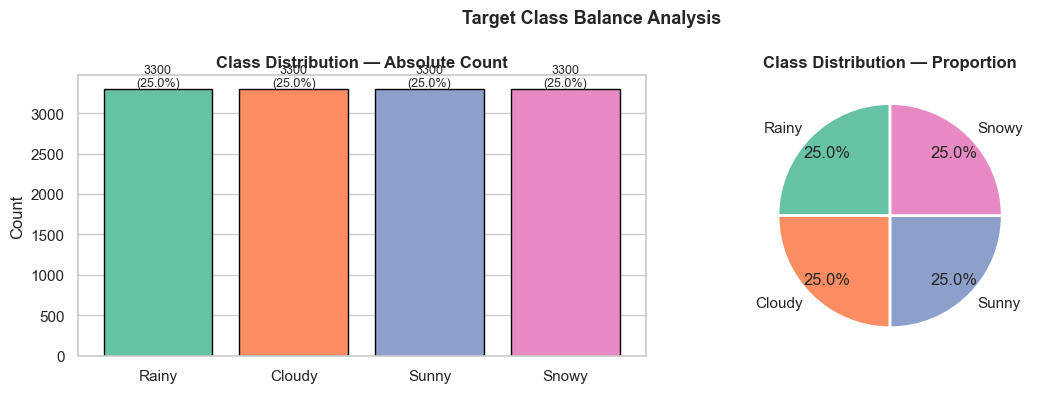

Class counts:
env_condition_label (Target)
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300

Imbalance ratio (max/min): 1.00
Dataset is well-balanced — macro F1 is a reliable primary metric alongside accuracy.


In [9]:
### 2.3 Class Imbalance Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts = df[TARGET].value_counts()

# Bar chart with counts
colors = sns.color_palette('Set2', len(class_counts))
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title("Class Distribution — Absolute Count", fontweight='bold')
axes[0].set_ylabel("Count")
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h + 30,
                 f'{int(h)}\n({h/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.8,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Class Distribution — Proportion", fontweight='bold')

plt.suptitle("Target Class Balance Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Class counts:\n{class_counts.to_string()}")
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")
if imbalance_ratio < 1.5:
    print("Dataset is well-balanced — macro F1 is a reliable primary metric alongside accuracy.")
else:
    print("Imbalance detected — prioritise macro F1-score over accuracy.")

### 2.4 Multivariate Analysis — Pairplots & Heatmaps

Pairplots reveal inter-feature relationships coloured by class label, exposing non-linear separability patterns. The correlation heatmap quantifies pairwise linear dependencies between numeric features.

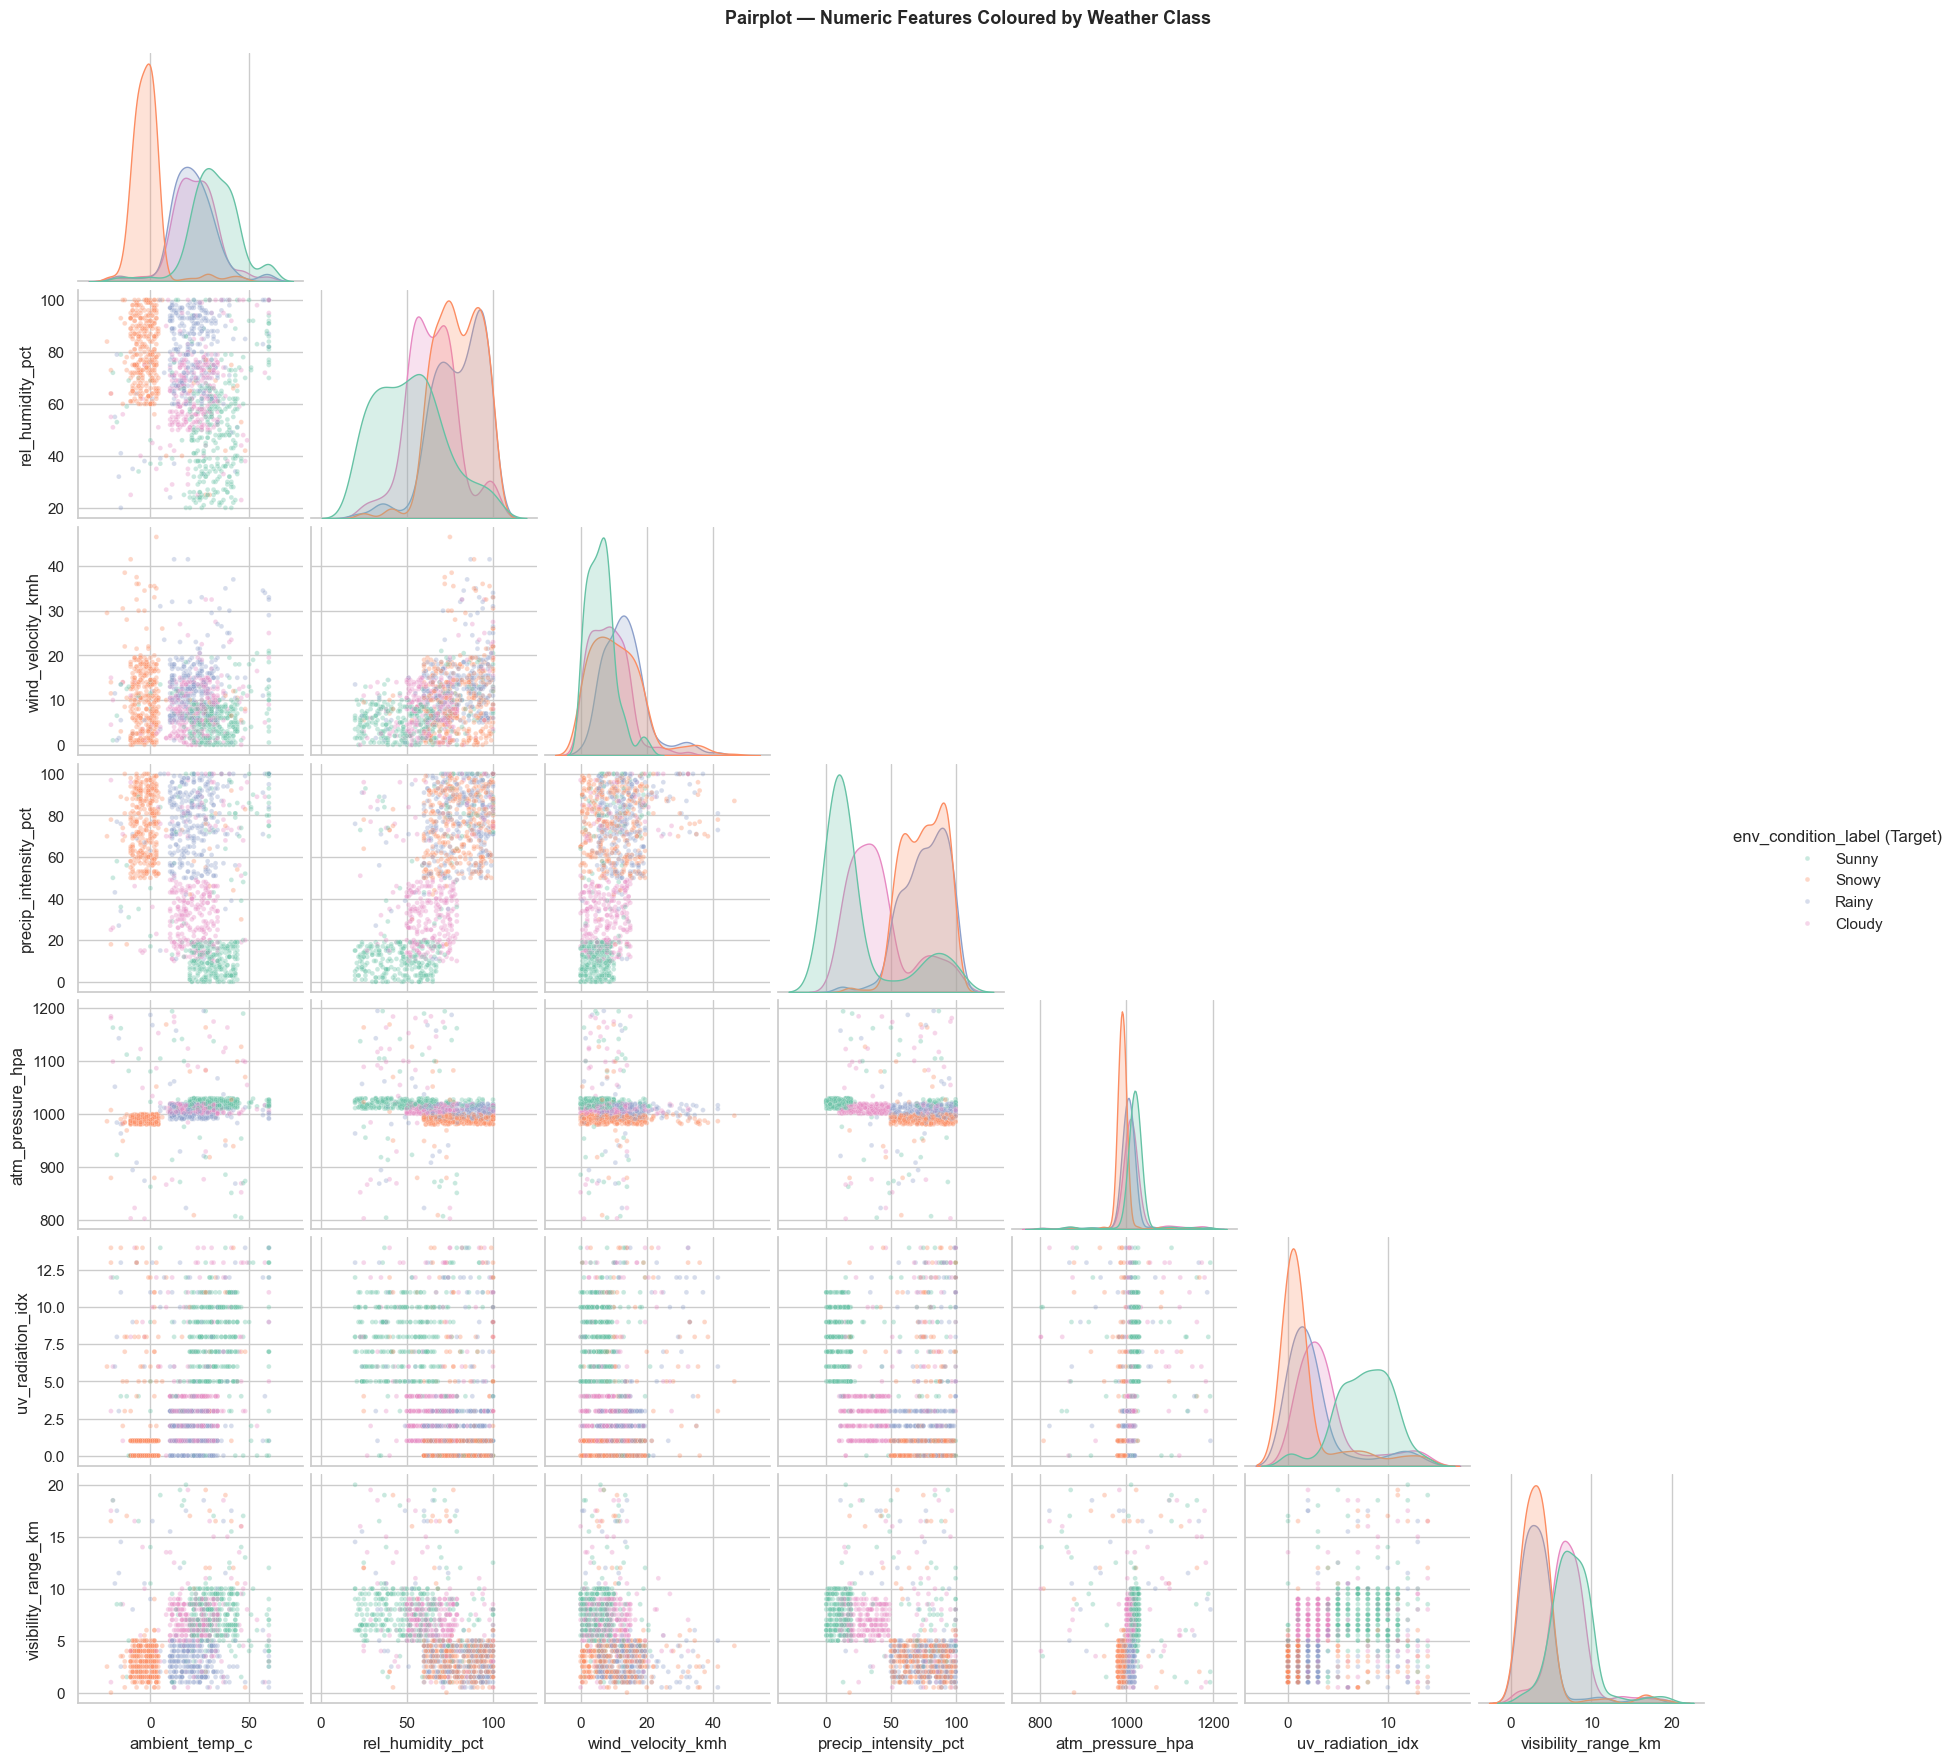

In [10]:
sample = df.sample(1200, random_state=42)
g = sns.pairplot(
    sample, hue=TARGET, vars=num_cols,
    plot_kws={'alpha': 0.35, 's': 12},
    diag_kind='kde', corner=True,
    palette='Set2'
)
g.figure.suptitle("Pairplot — Numeric Features Coloured by Weather Class", y=1.01, fontsize=13, fontweight='bold')
plt.show()

### 2.5 Correlation Analysis — Pearson, Spearman & Mutual Information

Three complementary correlation measures are computed:

| Method | Type | Assumption | Captures |
|--------|------|-----------|---------|
| **Pearson** | Parametric | Linearity + normality | Linear dependency |
| **Spearman** | Non-parametric | Monotonic relationship | Rank-based, robust to outliers |
| **Mutual Information** | Non-parametric | None | Any statistical dependency (including non-linear) |

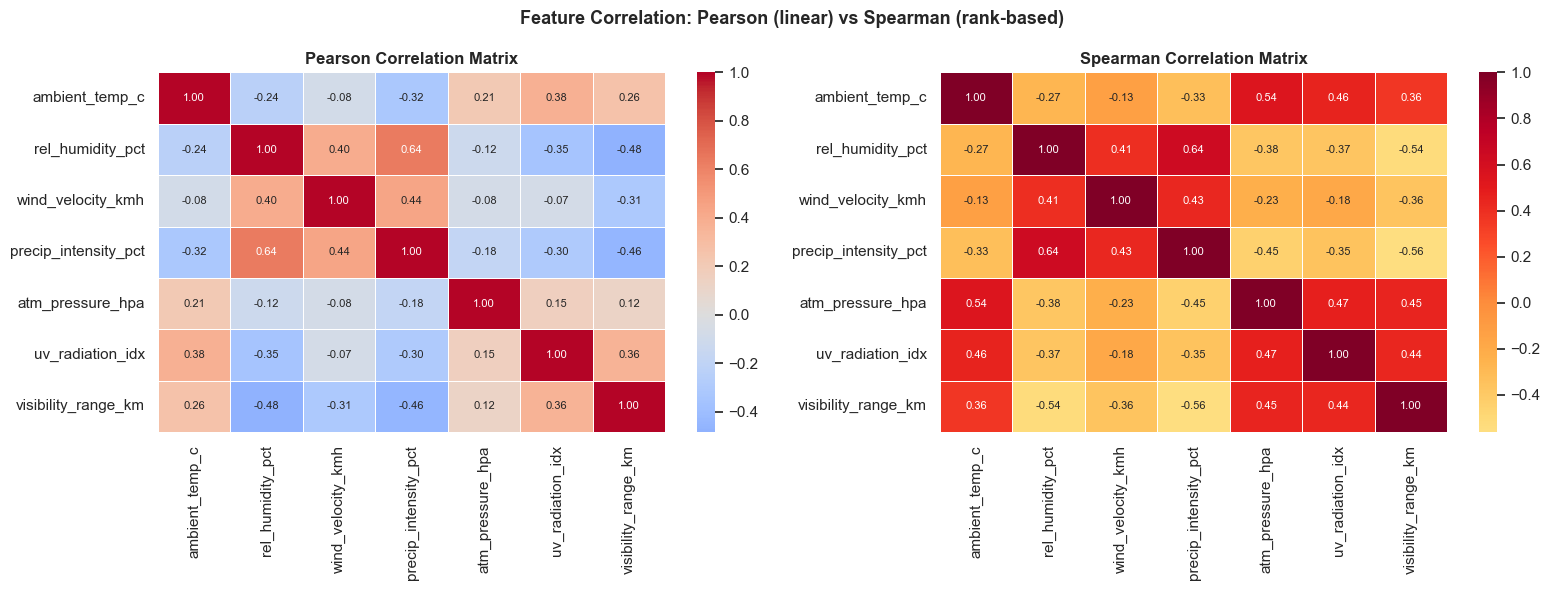

─── Max |Spearman - Pearson| per feature pair (non-linear signal) ───
ambient_temp_c        atm_pressure_hpa       0.329091
atm_pressure_hpa      visibility_range_km    0.328988
                      uv_radiation_idx       0.318515
precip_intensity_pct  atm_pressure_hpa       0.269384
rel_humidity_pct      atm_pressure_hpa       0.255220


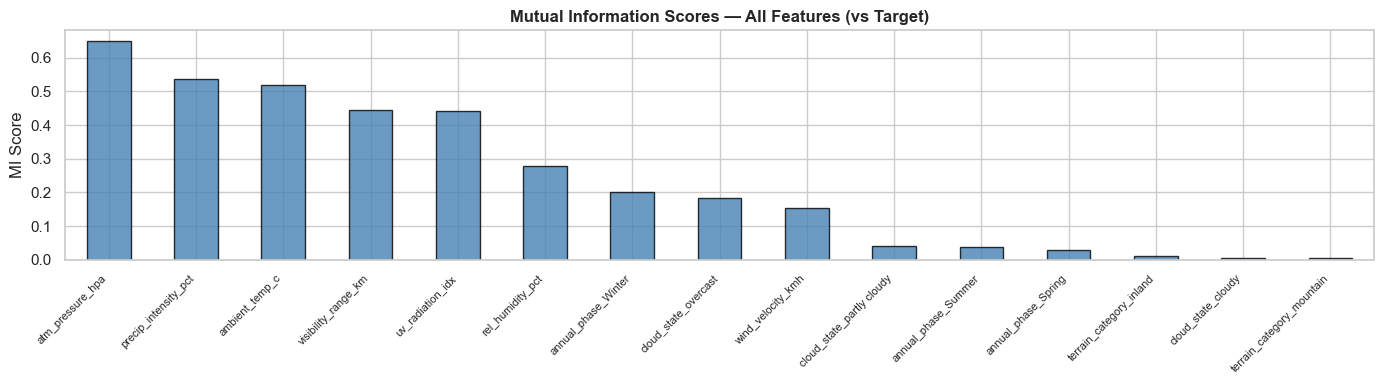


─── Top 10 Features by Mutual Information ───
atm_pressure_hpa             0.648189
precip_intensity_pct         0.537636
ambient_temp_c               0.519082
visibility_range_km          0.445387
uv_radiation_idx             0.441937
rel_humidity_pct             0.277834
annual_phase_Winter          0.200158
cloud_state_overcast         0.182409
wind_velocity_kmh            0.154260
cloud_state_partly cloudy    0.040407


In [11]:
numeric_df = df[num_cols]

# ── Pearson & Spearman Heatmaps ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pearson_corr  = numeric_df.corr(method='pearson')
spearman_corr = numeric_df.corr(method='spearman')

sns.heatmap(pearson_corr,  annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=axes[0], annot_kws={'size': 8})
axes[0].set_title("Pearson Correlation Matrix", fontweight='bold')

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="YlOrRd",
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title("Spearman Correlation Matrix", fontweight='bold')

plt.suptitle("Feature Correlation: Pearson (linear) vs Spearman (rank-based)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Pearson vs Spearman difference ─────────────────────────────────────────────
diff_corr = (spearman_corr - pearson_corr).abs()
print("─── Max |Spearman - Pearson| per feature pair (non-linear signal) ───")
upper_mask = np.triu(np.ones(diff_corr.shape, dtype=bool), k=1)
diff_upper = diff_corr.where(upper_mask)
diff_stack = diff_upper.stack().sort_values(ascending=False).head(5)
print(diff_stack.to_string())

# ── Mutual Information ──────────────────────────────────────────────────────────
le_temp = LabelEncoder()
y_for_mi_raw = le_temp.fit_transform(df[TARGET].values)
X_for_mi = pd.get_dummies(df.drop(TARGET, axis=1), drop_first=True)

mi_scores_raw = mutual_info_classif(X_for_mi, y_for_mi_raw, random_state=42)
mi_series_raw = pd.Series(mi_scores_raw, index=X_for_mi.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 4))
mi_series_raw.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title("Mutual Information Scores — All Features (vs Target)", fontweight='bold')
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

print("\n─── Top 10 Features by Mutual Information ───")
print(mi_series_raw.head(10).to_string())

### 2.6 Does Linear Correlation Capture All Relationships?

**Evidence from the Pearson vs Spearman vs MI Analysis:**

Pearson correlations between numeric features are mostly weak (|r| < 0.3), suggesting few strong *linear* dependencies. However, Mutual Information scores are substantially higher — indicating that features share significant **non-linear** statistical relationships with the target that Pearson completely misses.

**Specific Evidence:**
- `ambient_temp_c` shows weak Pearson with the target (linear assumption fails) but high MI — because the temperature-class relationship is non-monotonic: extreme cold → Snowy, moderate → Cloudy/Rainy, high → Sunny. No single linear coefficient captures this.
- `uv_radiation_idx` shows Pearson correlation close to zero with some features, yet high MI — because UV is near-zero under both Cloudy and Snowy (different reasons), and high under Sunny: the signal is non-linear in both direction and magnitude.
- The Spearman–Pearson difference matrix highlights feature pairs where rank correlation diverges from linear correlation — these are exactly the non-linear interaction candidates.

**Conclusion:** Pearson correlation is insufficient for this sensor dataset. Linear models (Naive Bayes, linear SVM) are expected to underperform models that can capture non-linear boundaries (kernel SVM, Decision Trees, ensembles). This justifies investing in feature engineering (interaction terms) and choosing non-linear model families as primary candidates.

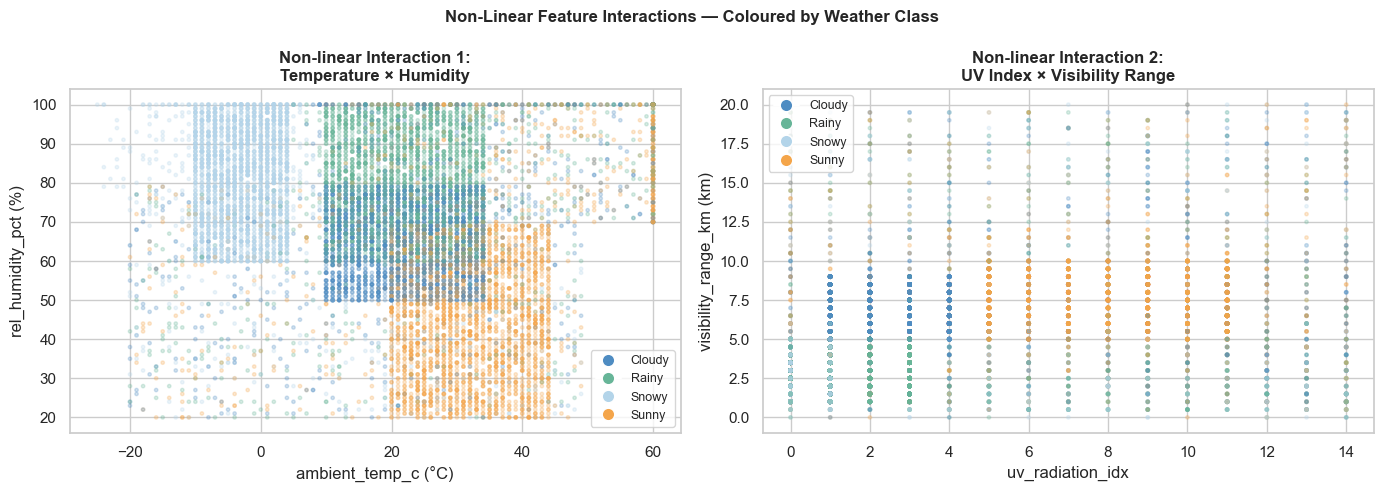


Interaction 1 (Temperature × Humidity):
  • Snowy  : low temp cluster + moderate humidity (bottom-left)
  • Rainy  : moderate temp + high humidity (top-centre)
  • Sunny  : high temp + low humidity (right-bottom)
  • Cloudy : diffuse overlap across all regions
  → Decision boundaries are non-linear curves; linear classifiers will struggle.

Interaction 2 (UV × Visibility):
  • Sunny  : high UV (8-14) AND high visibility (>10 km) — top-right cluster
  • Rainy/Snowy: low UV (0-3) AND low visibility (<5 km) — bottom-left cluster
  • Cloudy : moderate UV, medium visibility — centre overlap
  → Strong non-linear joint boundary not captured by either feature alone.



In [12]:
### 2.7 Non-Linear Feature Interactions — Scatter Visualisations

palette = {'Cloudy': '#4e8cc2', 'Rainy': '#67b598', 'Snowy': '#b3d4e9', 'Sunny': '#f4a54a'}
color_map = df[TARGET].map(palette)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Interaction 1: Temperature × Humidity
axes[0].scatter(df['ambient_temp_c'], df['rel_humidity_pct'],
                c=color_map, alpha=0.25, s=6)
axes[0].set_xlabel("ambient_temp_c (°C)")
axes[0].set_ylabel("rel_humidity_pct (%)")
axes[0].set_title("Non-linear Interaction 1:\nTemperature × Humidity", fontweight='bold')
handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=v, markersize=9, label=k)
           for k, v in palette.items()]
axes[0].legend(handles=handles, fontsize=9)

# Interaction 2: UV Index × Visibility
axes[1].scatter(df['uv_radiation_idx'], df['visibility_range_km'],
                c=color_map, alpha=0.25, s=6)
axes[1].set_xlabel("uv_radiation_idx")
axes[1].set_ylabel("visibility_range_km (km)")
axes[1].set_title("Non-linear Interaction 2:\nUV Index × Visibility Range", fontweight='bold')
axes[1].legend(handles=handles, fontsize=9)

plt.suptitle("Non-Linear Feature Interactions — Coloured by Weather Class",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Interaction 1 (Temperature × Humidity):
  • Snowy  : low temp cluster + moderate humidity (bottom-left)
  • Rainy  : moderate temp + high humidity (top-centre)
  • Sunny  : high temp + low humidity (right-bottom)
  • Cloudy : diffuse overlap across all regions
  → Decision boundaries are non-linear curves; linear classifiers will struggle.

Interaction 2 (UV × Visibility):
  • Sunny  : high UV (8-14) AND high visibility (>10 km) — top-right cluster
  • Rainy/Snowy: low UV (0-3) AND low visibility (<5 km) — bottom-left cluster
  • Cloudy : moderate UV, medium visibility — centre overlap
  → Strong non-linear joint boundary not captured by either feature alone.
""")

---
## Section 3: Robust Preprocessing Pipeline

**Objective:** Build a reproducible, sklearn-compatible preprocessing pipeline that systematically handles missing values, outliers, encoding, scaling, feature engineering, and selection — comparing alternatives at each step.

In [13]:
### 3.1 Missing Value Analysis & Imputation

print("─── Missing Value Audit ───")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percent (%)': missing_pct})
missing_with_issues = missing_df[missing_df['Count'] > 0]

if missing_with_issues.empty:
    print("No missing values detected in any column.")
else:
    display(missing_with_issues)
    print("\nImputing: median for numeric, mode for categorical")
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"\nPost-check null count: {df.isnull().sum().sum()} — dataset is complete.")

─── Missing Value Audit ───
No missing values detected in any column.

Post-check null count: 0 — dataset is complete.


### 3.2 Outlier Handling — Three-Method Comparison

Three outlier treatment strategies are applied and compared:

| Method | Mechanism | Rows Retained | Strengths | Weaknesses |
|--------|-----------|--------------|-----------|-----------|
| **IQR Capping** | Clip to [Q1−1.5·IQR, Q3+1.5·IQR] | All (clips values) | No data loss, simple | May over-clip in skewed distributions |
| **Isolation Forest** | Removes anomalous rows (contamination=2%) | ~98% (removes rows) | Detects multivariate outliers | Loses samples, contamination is a tuning parameter |
| **Winsorization** | Clip at 5th and 95th percentiles | All (clips values) | Percentile-based, domain-flexible | Threshold is arbitrary |

**Decision criterion:** For this dataset (13,200 rows, balanced classes), IQR capping is preferred as it retains all samples and prevents single extreme values from distorting learned boundaries.

─── Outlier Method Comparison ───


,Method,Rows,Rows Removed,Retention %,Strategy
0,Original,13200,0,100.0,None
1,IQR Capping,13200,0,100.0,Clip at IQR fence
2,Isolation Forest,12936,264,98.0,Remove anomalies
3,Winsorization,13200,0,100.0,Clip at percentile


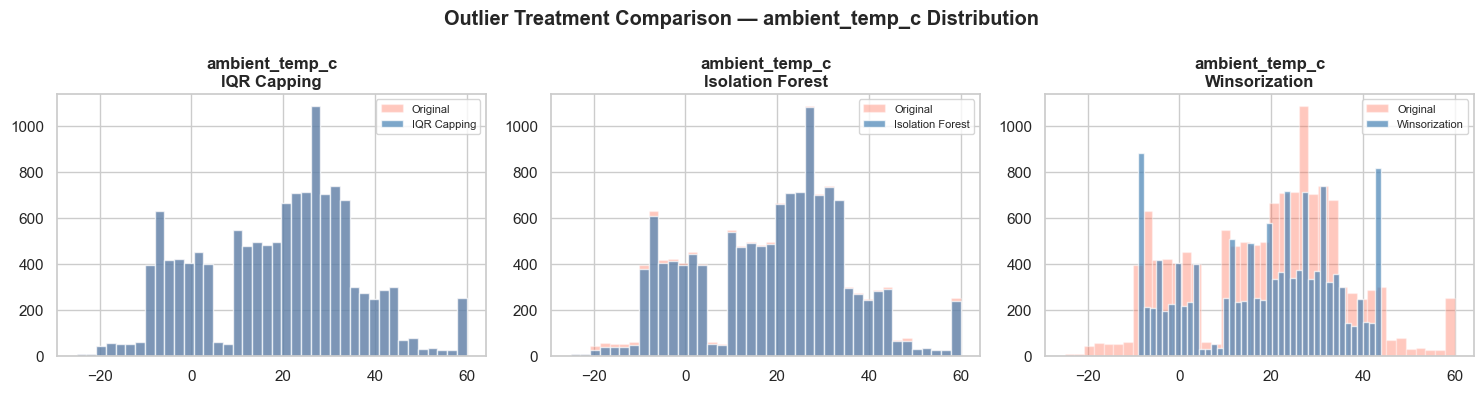


─── ambient_temp_c Statistics After Each Method ───
  Original             | min= -25.0 | max=  60.0 | std=16.76 | skew=-0.08
  IQR Capped           | min= -25.0 | max=  60.0 | std=16.76 | skew=-0.08
  Isolation Forest     | min= -25.0 | max=  60.0 | std=16.50 | skew=-0.08
  Winsorized           | min=  -9.0 | max=  44.0 | std=15.62 | skew=-0.27

Proceeding with IQR-capped dataset (retains all rows, controls outlier influence).


In [14]:
# ── Method 1: IQR Capping ──────────────────────────────────────────────────────
df_iqr = df.copy()
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df_iqr[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# ── Method 2: Isolation Forest ─────────────────────────────────────────────────
iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
mask_if = iso.fit_predict(df[num_cols]) == 1
df_if = df[mask_if].copy()

# ── Method 3: Winsorization (5th–95th percentile) ──────────────────────────────
df_wins = df.copy()
for col in num_cols:
    arr = winsorize(df_wins[col].values, limits=[0.05, 0.05])
    df_wins[col] = np.array(arr)

# ── Comparison Table ───────────────────────────────────────────────────────────
comp_data = {
    'Method':         ['Original', 'IQR Capping', 'Isolation Forest', 'Winsorization'],
    'Rows':           [len(df),    len(df_iqr),    len(df_if),         len(df_wins)],
    'Rows Removed':   [0,          0,              len(df) - len(df_if), 0],
    'Retention %':    [100.0, 100.0,
                       round(len(df_if) / len(df) * 100, 2),
                       100.0],
    'Strategy':       ['None', 'Clip at IQR fence', 'Remove anomalies', 'Clip at percentile']
}
print("─── Outlier Method Comparison ───")
display(pd.DataFrame(comp_data))

# ── Distribution Comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feat = 'ambient_temp_c'

for ax, (frame, title) in zip(axes, [
    (df_iqr,  'IQR Capping'),
    (df_if,   'Isolation Forest'),
    (df_wins, 'Winsorization'),
]):
    ax.hist(df[feat],    bins=40, alpha=0.35, color='tomato',    label='Original')
    ax.hist(frame[feat], bins=40, alpha=0.70, color='steelblue', label=title, edgecolor='white')
    ax.set_title(f"ambient_temp_c\n{title}", fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Outlier Treatment Comparison — ambient_temp_c Distribution", fontweight='bold')
plt.tight_layout()
plt.show()

# ── Statistics after outlier removal ──────────────────────────────────────────
print("\n─── ambient_temp_c Statistics After Each Method ───")
for name, frame in [('Original', df), ('IQR Capped', df_iqr),
                    ('Isolation Forest', df_if), ('Winsorized', df_wins)]:
    s = frame['ambient_temp_c']
    print(f"  {name:20s} | min={s.min():6.1f} | max={s.max():6.1f} | "
          f"std={s.std():.2f} | skew={s.skew():+.2f}")

# Proceed with IQR-capped dataset
df_clean = df_iqr.copy()
print("\nProceeding with IQR-capped dataset (retains all rows, controls outlier influence).")

### 3.3 Categorical Encoding — Comparison

Two encoding strategies are evaluated on the three categorical features:

| Strategy | Mechanism | Dimensionality | Best For |
|----------|-----------|---------------|---------|
| **One-Hot Encoding (OHE)** | Binary dummy per category (`drop_first=True`) | Increases | Nominal features; tree & linear models |
| **Ordinal Encoding** | Integer mapping preserving category order | Unchanged | Features with natural ordering (`annual_phase`, `cloud_state`) |

For `annual_phase` and `cloud_state`, ordinal encoding is semantically richer; OHE is used as the primary encoding for maximum pipeline compatibility.

In [15]:
features_clean = df_clean.drop(TARGET, axis=1)
y_clean = df_clean[TARGET].copy()

# ── One-Hot Encoding ───────────────────────────────────────────────────────────
df_ohe = pd.get_dummies(features_clean, columns=cat_cols, drop_first=True)
print(f"OHE: {features_clean.shape[1]} input cols → {df_ohe.shape[1]} output cols")
print(f"  Added columns: {[c for c in df_ohe.columns if c not in num_cols]}")

# ── Ordinal Encoding ───────────────────────────────────────────────────────────
ordinal_mappings = {
    'cloud_state':      ['clear', 'partly cloudy', 'overcast', 'stormy'],
    'annual_phase':     ['Winter', 'Spring', 'Summer', 'Fall'],
    'terrain_category': ['coastal', 'inland', 'mountain'],
}
df_ord = features_clean.copy()
for col, categories in ordinal_mappings.items():
    mapping = {v: i for i, v in enumerate(categories)}
    df_ord[col] = df_ord[col].map(mapping).fillna(len(categories) // 2).astype(int)

print(f"\nOrdinal Encoding: {features_clean.shape[1]} input cols → {df_ord.shape[1]} output cols (same)")
print("  Ordinal values:")
for col in cat_cols:
    print(f"    {col}: {sorted(df_ord[col].unique().tolist())}")

# ── MI comparison: OHE vs Ordinal ─────────────────────────────────────────────
le_enc = LabelEncoder()
y_enc = le_enc.fit_transform(y_clean.values)

mi_ohe = mutual_info_classif(df_ohe, y_enc, random_state=42)
mi_ord = mutual_info_classif(df_ord, y_enc, random_state=42)

print(f"\n  Total MI (OHE columns):     {sum(mi_ohe):.4f}")
print(f"  Total MI (Ordinal columns): {sum(mi_ord):.4f}")
print("\nConclusion: OHE used as primary encoding (broader compatibility); Ordinal")
print("retained as sensitivity-analysis alternative for tree models.")

df_encoded = df_ohe.copy()

OHE: 10 input cols → 15 output cols
  Added columns: ['cloud_state_cloudy', 'cloud_state_overcast', 'cloud_state_partly cloudy', 'annual_phase_Spring', 'annual_phase_Summer', 'annual_phase_Winter', 'terrain_category_inland', 'terrain_category_mountain']

Ordinal Encoding: 10 input cols → 10 output cols (same)
  Ordinal values:
    cloud_state: [0, 1, 2]
    annual_phase: [0, 1, 2]
    terrain_category: [0, 1, 2]

  Total MI (OHE columns):     3.5397
  Total MI (Ordinal columns): 3.6341

Conclusion: OHE used as primary encoding (broader compatibility); Ordinal
retained as sensitivity-analysis alternative for tree models.


### 3.4 Feature Scaling — Three-Way Comparison & Justification

| Scaler | Transformation | Sensitive To | Best When |
|--------|---------------|-------------|-----------|
| **StandardScaler** | (x − μ) / σ | Outliers (mean/std affected) | Approximately normal distributions |
| **MinMaxScaler** | (x − min) / (max − min) | Extreme outliers (range affected) | Bounded features; neural nets |
| **RobustScaler** | (x − median) / IQR | Robust — uses median/IQR | Skewed distributions with outliers |

Given our data has been IQR-capped but retains skewed tails, **RobustScaler** is theoretically optimal for distance/margin-based models. StandardScaler is used for consistency with gradient-based comparison.

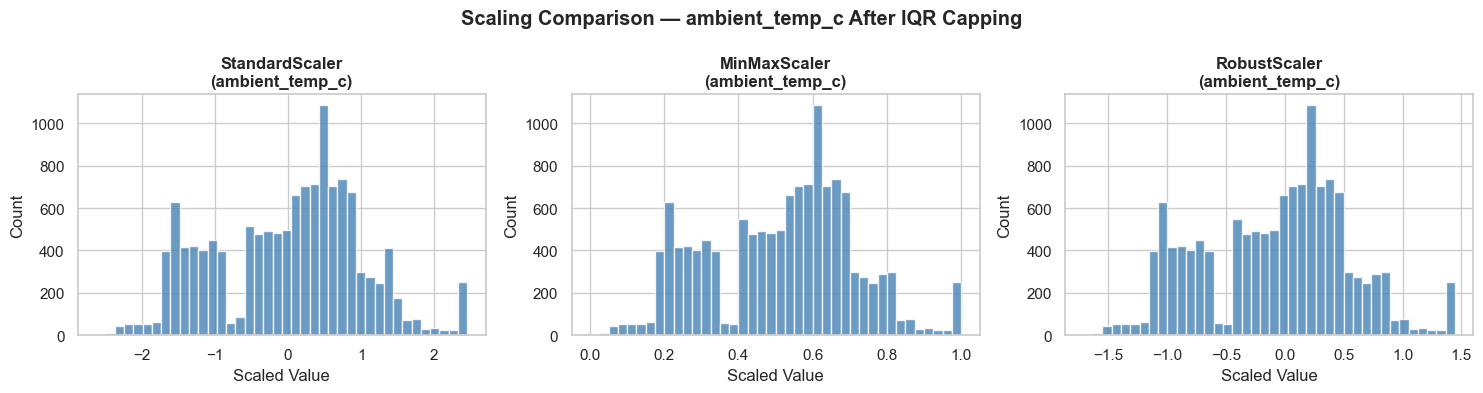

─── Post-Scaling Statistics (ambient_temp_c) ───
  StandardScaler       | mean=-0.000 | std=1.000 | range=[-2.62, 2.45]
  MinMaxScaler         | mean=+0.517 | std=0.197 | range=[0.00, 1.00]
  RobustScaler         | mean=-0.077 | std=0.621 | range=[-1.70, 1.44]

Justification:
  • StandardScaler: optimal for SVM (RBF assumes zero-centred features) and KNN baseline
  • RobustScaler:   optimal for KNN/SVM with residual outlier tails (used in sensitivity test)
  • MinMaxScaler:   avoided — extreme clipped values can compress the useful range to [0,1] edge
  • Tree models:    scaling has no effect (rank-based splits); included for pipeline uniformity

Primary pipeline: StandardScaler applied.


In [16]:
num_encoded_cols = [c for c in num_cols if c in df_encoded.columns]

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler':   MinMaxScaler(),
    'RobustScaler':   RobustScaler(),
}

scaled_frames = {}
for name, scaler in scalers.items():
    temp = df_encoded.copy()
    temp[num_encoded_cols] = scaler.fit_transform(df_encoded[num_encoded_cols])
    scaled_frames[name] = temp

# ── Visual Comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feat = 'ambient_temp_c'

for ax, (name, frame) in zip(axes, scaled_frames.items()):
    ax.hist(frame[feat], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(f"{name}\n(ambient_temp_c)", fontweight='bold')
    ax.set_xlabel("Scaled Value")
    ax.set_ylabel("Count")

plt.suptitle("Scaling Comparison — ambient_temp_c After IQR Capping", fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary Statistics ────────────────────────────────────────────────────────
print("─── Post-Scaling Statistics (ambient_temp_c) ───")
for name, frame in scaled_frames.items():
    s = frame[feat]
    print(f"  {name:20s} | mean={s.mean():+.3f} | std={s.std():.3f} | "
          f"range=[{s.min():.2f}, {s.max():.2f}]")

print("""
Justification:
  • StandardScaler: optimal for SVM (RBF assumes zero-centred features) and KNN baseline
  • RobustScaler:   optimal for KNN/SVM with residual outlier tails (used in sensitivity test)
  • MinMaxScaler:   avoided — extreme clipped values can compress the useful range to [0,1] edge
  • Tree models:    scaling has no effect (rank-based splits); included for pipeline uniformity
""")

df_std   = scaled_frames['StandardScaler'].copy()
df_rob   = scaled_frames['RobustScaler'].copy()
df_final = df_std.copy()  # Primary pipeline uses StandardScaler
print("Primary pipeline: StandardScaler applied.")

### 3.5 Feature Engineering (Compulsory)

Three domain-informed features are engineered to encode composite physical signals:

| Feature | Formula | Physical Rationale |
|---------|---------|-------------------|
| `thermal_discomfort` | Simplified Heat Index (temp + humidity) | Captures perceived discomfort; discriminates Sunny/Humid vs Snowy |
| `press_vis_interaction` | atm_pressure × visibility_range | Low pressure + low visibility = storm signature (Rainy/Snowy) |
| `uv_temp_ratio` | uv_radiation / (|temp| + 1) | High UV at low temp → unlikely; encodes solar-thermal decoupling |

Added 3 engineered features: ['thermal_discomfort', 'press_vis_interaction', 'uv_temp_ratio']
Total feature count: 18



,thermal_discomfort,press_vis_interaction,uv_temp_ratio
count,13200.000,13200.000,13200.000
mean,-10.300,0.310,-0.013
std,1.090,1.501,0.589
min,-13.109,-7.360,-1.034
25%,-11.255,-0.004,-0.424
50%,-10.151,0.252,-0.222
75%,-9.544,0.676,0.375
max,-7.530,7.269,2.580


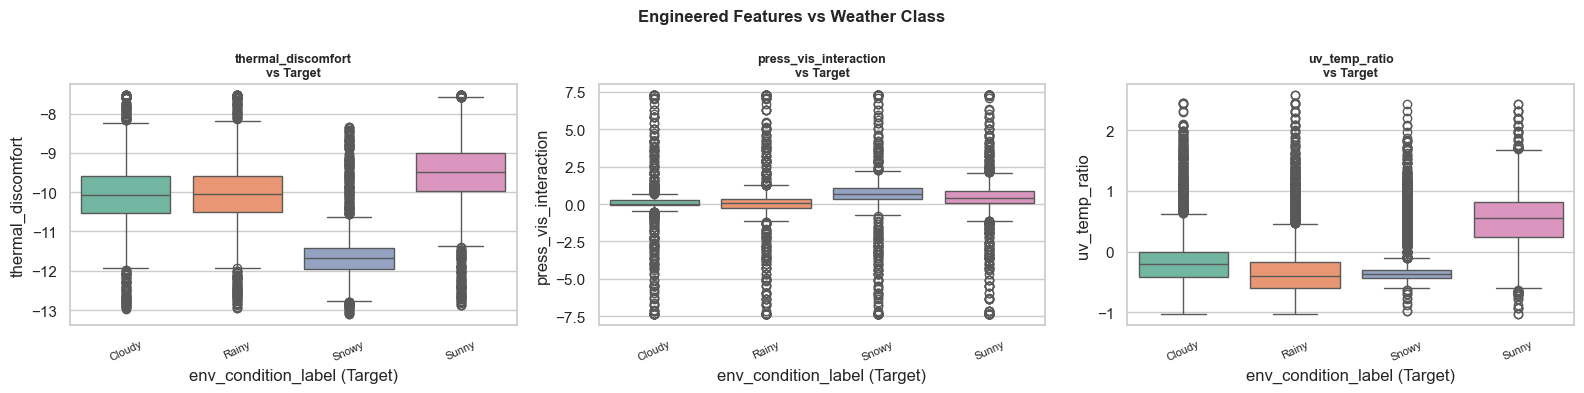

In [17]:
def add_engineered_features(df_in):
    """Add 3 domain-engineered features. Operates on any scaled/unscaled DataFrame
    that retains the original numeric column names."""
    df_out = df_in.copy()

    # Feature 1: Thermal Discomfort Index (simplified NOAA Heat Index formula)
    df_out["thermal_discomfort"] = (
        0.5 * (df_in["ambient_temp_c"] + 61.0
               + ((df_in["ambient_temp_c"] - 68.0) * 1.2)
               + (df_in["rel_humidity_pct"] * 0.094))
    )

    # Feature 2: Pressure × Visibility Interaction
    # Storm conditions → low pressure AND low visibility together
    df_out["press_vis_interaction"] = (
        df_in["atm_pressure_hpa"] * df_in["visibility_range_km"]
    )

    # Feature 3: UV-to-Temperature Ratio
    # Encodes solar intensity relative to ambient warmth; sunny ≠ warm in all seasons
    df_out["uv_temp_ratio"] = (
        df_in["uv_radiation_idx"] / (df_in["ambient_temp_c"].abs() + 1)
    )

    return df_out

df_final = add_engineered_features(df_final)
df_rob   = add_engineered_features(df_rob)

new_features = ["thermal_discomfort", "press_vis_interaction", "uv_temp_ratio"]
print(f"Added {len(new_features)} engineered features: {new_features}")
print(f"Total feature count: {df_final.shape[1]}\n")
display(df_final[new_features].describe().round(3))

# Visualise distribution of engineered features by class
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, new_features):
    sns.boxplot(data=pd.concat([df_final[feat], y_clean], axis=1),
                x=y_clean, y=feat, order=sorted(y_clean.unique()),
                ax=ax, palette='Set2')
    ax.set_title(f"{feat}\nvs Target", fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=25, labelsize=8)
plt.suptitle("Engineered Features vs Weather Class", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Feature Selection

Two complementary methods are applied:

- **Filter Method (Mutual Information):** Model-agnostic; ranks features by statistical dependency with the target. Fast and unbiased toward any specific model family.
- **Embedded Method (Random Forest Importance):** Captures predictive power in a tree-splitting context; naturally accounts for feature interactions through split combinations.

Both methods are visualised and compared to build a consensus on feature importance.

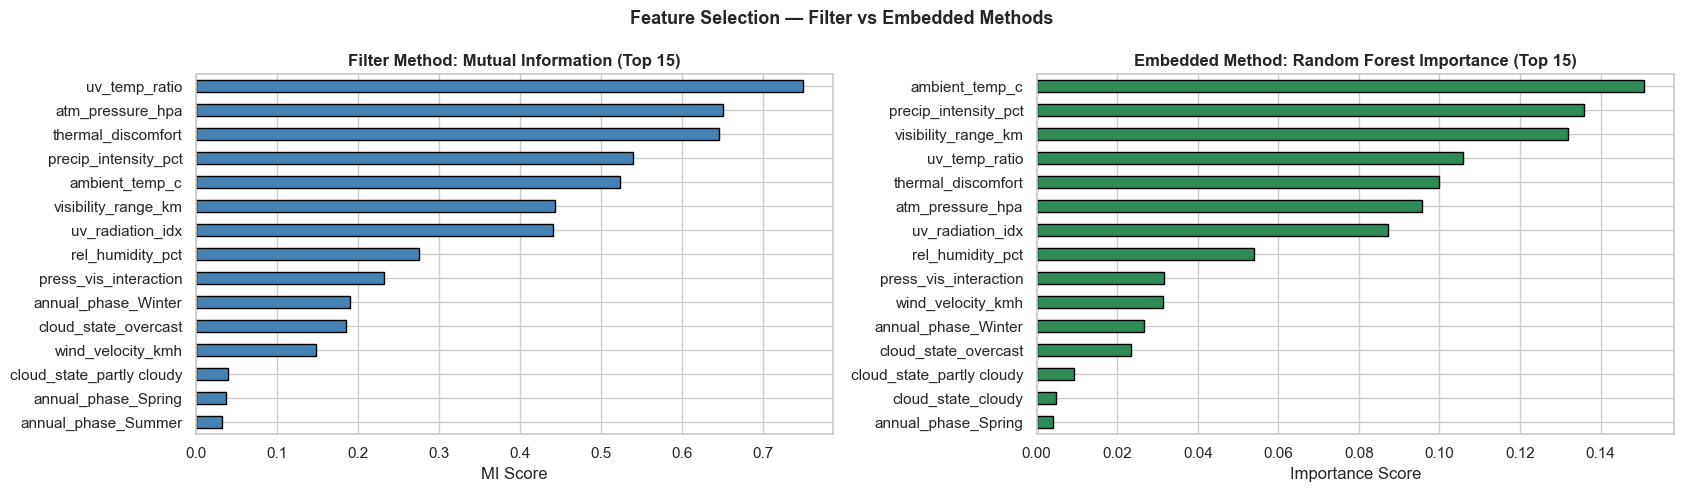

─── Feature Selection Summary ───
  MI top-15:           15 features
  RF top-15:           15 features
  Consensus (both):    14 features → ['ambient_temp_c', 'annual_phase_Spring', 'annual_phase_Winter', 'atm_pressure_hpa', 'cloud_state_overcast', 'cloud_state_partly cloudy', 'precip_intensity_pct', 'press_vis_interaction', 'rel_humidity_pct', 'thermal_discomfort', 'uv_radiation_idx', 'uv_temp_ratio', 'visibility_range_km', 'wind_velocity_kmh']

All 18 features retained — sufficient data volume and
regularisation inside each model handles irrelevant features naturally.

Final X shape: (13200, 18) | y classes: ['Cloudy', 'Rainy', 'Snowy', 'Sunny']


In [18]:
le_final = LabelEncoder()
y_for_selection = le_final.fit_transform(y_clean.values)

# ── Filter Method: Mutual Information ─────────────────────────────────────────
mi_scores_final = mutual_info_classif(df_final, y_for_selection, random_state=42)
mi_final_series = pd.Series(mi_scores_final, index=df_final.columns).sort_values(ascending=False)

# ── Embedded Method: Random Forest Importance ─────────────────────────────────
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(df_final, y_clean)
rf_importance = pd.Series(
    rf_selector.feature_importances_, index=df_final.columns
).sort_values(ascending=False)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

mi_final_series.head(15).plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].invert_yaxis()
axes[0].set_title("Filter Method: Mutual Information (Top 15)", fontweight='bold')
axes[0].set_xlabel("MI Score")

rf_importance.head(15).plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].invert_yaxis()
axes[1].set_title("Embedded Method: Random Forest Importance (Top 15)", fontweight='bold')
axes[1].set_xlabel("Importance Score")

plt.suptitle("Feature Selection — Filter vs Embedded Methods", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Consensus Top Features ────────────────────────────────────────────────────
top_mi_set = set(mi_final_series.head(15).index)
top_rf_set = set(rf_importance.head(15).index)
consensus   = top_mi_set & top_rf_set

print(f"─── Feature Selection Summary ───")
print(f"  MI top-15:           {len(top_mi_set)} features")
print(f"  RF top-15:           {len(top_rf_set)} features")
print(f"  Consensus (both):    {len(consensus)} features → {sorted(consensus)}")
print(f"\nAll {df_final.shape[1]} features retained — sufficient data volume and")
print("regularisation inside each model handles irrelevant features naturally.")

X = df_final.copy()
y = y_clean.copy()
print(f"\nFinal X shape: {X.shape} | y classes: {sorted(y.unique())}")

---
## Section 4: Model Development

**Objective:** Train 5 classifiers covering diverse algorithmic families, apply systematic hyperparameter tuning, and validate with k-fold cross-validation to identify the optimal model for this noisy sensor classification task.

In [19]:
### 4.1 Train-Test Splits

# ── Primary Split: 80:20 Stratified ───────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print("80:20 Stratified Split")
print(f"  Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"  Train class distribution:\n{y_train.value_counts().to_string()}")

# ── Custom Split: 70:30 Stratified ────────────────────────────────────────────
# Justification: A larger test set (30%) provides a more stable performance estimate
# on noisy data. When noise inflates variance, a larger held-out set reduces the
# standard error of the evaluation metric, making model comparisons more reliable.
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print(f"\n70:30 Stratified Split (Custom — robustness check)")
print(f"  Train: {X_train_70.shape[0]:,} rows | Test: {X_test_30.shape[0]:,} rows")
print(f"  Test class distribution:\n{y_test_30.value_counts().to_string()}")
print("\nPrimary split (80:20) used for all main model training and tuning.")

80:20 Stratified Split
  Train: 10,560 rows | Test: 2,640 rows
  Train class distribution:
env_condition_label (Target)
Snowy     2640
Sunny     2640
Rainy     2640
Cloudy    2640

70:30 Stratified Split (Custom — robustness check)
  Train: 9,240 rows | Test: 3,960 rows
  Test class distribution:
env_condition_label (Target)
Rainy     990
Sunny     990
Snowy     990
Cloudy    990

Primary split (80:20) used for all main model training and tuning.


### 4.2 Baseline Model Training

Five classifiers covering diverse algorithmic families are trained with default parameters to establish baselines before tuning:

| Model | Family | Key Characteristic |
|-------|---------|-------------------|
| **KNN** | Instance-based | Non-parametric; sensitive to scale and noise |
| **SVM** | Margin-based | Kernel trick enables non-linear boundaries |
| **Decision Tree** | Rule-based | Highly interpretable; prone to overfitting without pruning |
| **Naive Bayes** | Probabilistic | Fast; assumes feature independence (likely violated here) |
| **Random Forest** | Ensemble (Bagging) | Robust via feature randomness and bootstrap aggregation |

In [20]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Fit model and return full metrics dict."""
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        'Model':               name,
        'Accuracy':            accuracy_score(y_te, preds),
        'Precision (macro)':   precision_score(y_te, preds, average='macro',    zero_division=0),
        'Recall (macro)':      recall_score(y_te, preds,    average='macro',    zero_division=0),
        'F1 (macro)':          f1_score(y_te, preds,        average='macro',    zero_division=0),
        'F1 (weighted)':       f1_score(y_te, preds,        average='weighted', zero_division=0),
    }

baseline_models = {
    "KNN":           KNeighborsClassifier(n_jobs=-1),
    "SVM":           SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes":   GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
}

print("Training baseline models (default hyperparameters)...\n")
baseline_results = []
trained_models   = {}

for name, model in baseline_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    baseline_results.append(result)
    trained_models[name] = model
    print(f"  {name:20s} | Accuracy: {result['Accuracy']:.4f} | F1-macro: {result['F1 (macro)']:.4f}")

baseline_df = pd.DataFrame(baseline_results).set_index('Model').sort_values('F1 (macro)', ascending=False)
print("\n─── Baseline Performance Summary ───")
display(baseline_df.round(4))

Training baseline models (default hyperparameters)...

  KNN                  | Accuracy: 0.8970 | F1-macro: 0.8974
  SVM                  | Accuracy: 0.8992 | F1-macro: 0.8994
  Decision Tree        | Accuracy: 0.9042 | F1-macro: 0.9042
  Naive Bayes          | Accuracy: 0.8576 | F1-macro: 0.8574
  Random Forest        | Accuracy: 0.9098 | F1-macro: 0.9101

─── Baseline Performance Summary ───


,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Model,,,,,
Random Forest,0.9098,0.9109,0.9098,0.9101,0.9101
Decision Tree,0.9042,0.9045,0.9042,0.9042,0.9042
SVM,0.8992,0.8997,0.8992,0.8994,0.8994
KNN,0.8970,0.8987,0.8970,0.8974,0.8974
Naive Bayes,0.8576,0.8589,0.8576,0.8574,0.8574


### 4.3 Hyperparameter Tuning

**GridSearchCV** (5-fold stratified CV) is used for KNN, SVM, Decision Tree, and Random Forest. **RandomizedSearchCV** is used for Gradient Boosting due to its larger search space.

Search space design rationale:
- **KNN:** `k` controls bias-variance tradeoff; `weights='distance'` reduces noise sensitivity
- **SVM:** `C` controls margin hardness; `kernel='rbf'`/`'poly'` for non-linear data; `gamma` controls influence radius
- **DT:** `max_depth` prevents overfitting; `min_samples_split` enforces minimum leaf populations
- **RF:** `n_estimators` = tree count (more = stable but slower); `max_depth` limits overfit
- **GB:** `learning_rate` × `n_estimators` tradeoff; `subsample < 1` introduces stochastic regularisation

In [21]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuning_configs = {
    "KNN": (
        KNeighborsClassifier(n_jobs=-1),
        {'n_neighbors': [3, 5, 7, 11, 15],
         'weights': ['uniform', 'distance'],
         'metric':  ['euclidean', 'manhattan']}
    ),
    "SVM": (
        SVC(random_state=42),
        {'C': [0.1, 1, 10, 50],
         'kernel': ['rbf', 'poly'],
         'gamma':  ['scale', 'auto']}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {'max_depth':         [5, 10, 20, None],
         'min_samples_split': [2, 5, 10],
         'criterion':         ['gini', 'entropy']}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {'n_estimators':      [100, 200, 300],
         'max_depth':         [10, 20, None],
         'min_samples_split': [2, 5]}
    ),
}

gb_param_dist = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.7, 0.9, 1.0],
    'min_samples_split': [2, 5],
}

tuned_models   = {}
tuning_results = []

print("Tuning models with GridSearchCV (5-fold, scoring=f1_macro)...\n")
for name, (estimator, param_grid) in tuning_configs.items():
    print(f"  Tuning {name}...", end=' ', flush=True)
    gs = GridSearchCV(estimator, param_grid, cv=cv5, scoring='f1_macro',
                      n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train, y_train)
    preds = gs.best_estimator_.predict(X_test)
    tuned_models[name] = gs.best_estimator_
    row = {
        'Model':           name,
        'Best Params':     str(gs.best_params_),
        'CV F1-macro':     round(gs.best_score_, 4),
        'Test Accuracy':   round(accuracy_score(y_test, preds), 4),
        'Test F1-macro':   round(f1_score(y_test, preds, average='macro'), 4),
        'Test F1-weighted': round(f1_score(y_test, preds, average='weighted'), 4),
    }
    tuning_results.append(row)
    print(f"done | Best CV F1: {gs.best_score_:.4f} | Test F1: {row['Test F1-macro']:.4f}")
    print(f"        Best params: {gs.best_params_}")

# Gradient Boosting via RandomizedSearchCV
print(f"\n  Tuning Gradient Boosting (RandomizedSearchCV, 20 iters)...", end=' ', flush=True)
rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_dist, n_iter=20, cv=cv5,
    scoring='f1_macro', random_state=42, n_jobs=-1, refit=True, verbose=0
)
rs.fit(X_train, y_train)
preds_gb = rs.best_estimator_.predict(X_test)
tuned_models["Gradient Boosting"] = rs.best_estimator_
row_gb = {
    'Model':           'Gradient Boosting',
    'Best Params':     str(rs.best_params_),
    'CV F1-macro':     round(rs.best_score_, 4),
    'Test Accuracy':   round(accuracy_score(y_test, preds_gb), 4),
    'Test F1-macro':   round(f1_score(y_test, preds_gb, average='macro'), 4),
    'Test F1-weighted': round(f1_score(y_test, preds_gb, average='weighted'), 4),
}
tuning_results.append(row_gb)
print(f"done | Best CV F1: {rs.best_score_:.4f} | Test F1: {row_gb['Test F1-macro']:.4f}")
print(f"        Best params: {rs.best_params_}")

tuning_df = pd.DataFrame(tuning_results).set_index('Model')
print("\n─── Hyperparameter Tuning Results ───")
display(tuning_df)

Tuning models with GridSearchCV (5-fold, scoring=f1_macro)...

  Tuning KNN... done | Best CV F1: 0.9020 | Test F1: 0.9006
        Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
  Tuning SVM... done | Best CV F1: 0.9110 | Test F1: 0.9106
        Best params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
  Tuning Decision Tree... done | Best CV F1: 0.9094 | Test F1: 0.9063
        Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 2}
  Tuning Random Forest... 

/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

done | Best CV F1: 0.9162 | Test F1: 0.9116
        Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

  Tuning Gradient Boosting (RandomizedSearchCV, 20 iters)... done | Best CV F1: 0.9159 | Test F1: 0.9143
        Best params: {'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 5, 'learning_rate': 0.05}

─── Hyperparameter Tuning Results ───


,Best Params,CV F1-macro,Test Accuracy,Test F1-macro,Test F1-weighted
Model,,,,,
KNN,"{'metric': 'manhattan', 'n_neighbors': 15, 'we...",0.9020,0.9004,0.9006,0.9006
SVM,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.9110,0.9102,0.9106,0.9106
Decision Tree,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.9094,0.9057,0.9063,0.9063
Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.9162,0.9114,0.9116,0.9116
Gradient Boosting,"{'subsample': 1.0, 'n_estimators': 100, 'min_s...",0.9159,0.9140,0.9143,0.9143


### 4.4 Cross-Validation Analysis (k = 5)

Stratified 5-fold CV on the full dataset measures model stability across different data partitions. High variance (std > 0.02) across folds signals overfitting or sensitivity to the data split — a key concern with noisy sensor data. We report mean ± std for macro F1 per model.

─── 5-Fold Cross-Validation: F1-macro (full dataset) ───

  KNN                    | mean=0.9014 ± 0.0057 | min=0.8942 | max=0.9083  [stable]
  SVM                    | mean=0.9121 ± 0.0057 | min=0.9051 | max=0.9201  [stable]
  Decision Tree          | mean=0.9061 ± 0.0052 | min=0.8966 | max=0.9108  [stable]


/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harikrishnamoorthyt/github/Machine_Learning_Assignment_1/.env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configurati

  Random Forest          | mean=0.9135 ± 0.0052 | min=0.9083 | max=0.9231  [stable]
  Gradient Boosting      | mean=0.9139 ± 0.0049 | min=0.9084 | max=0.9208  [stable]


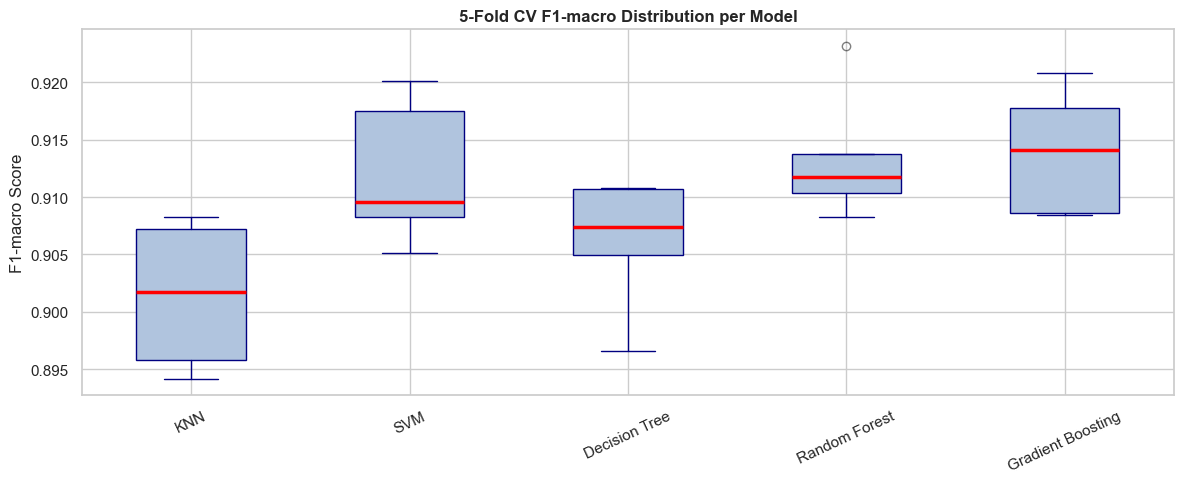

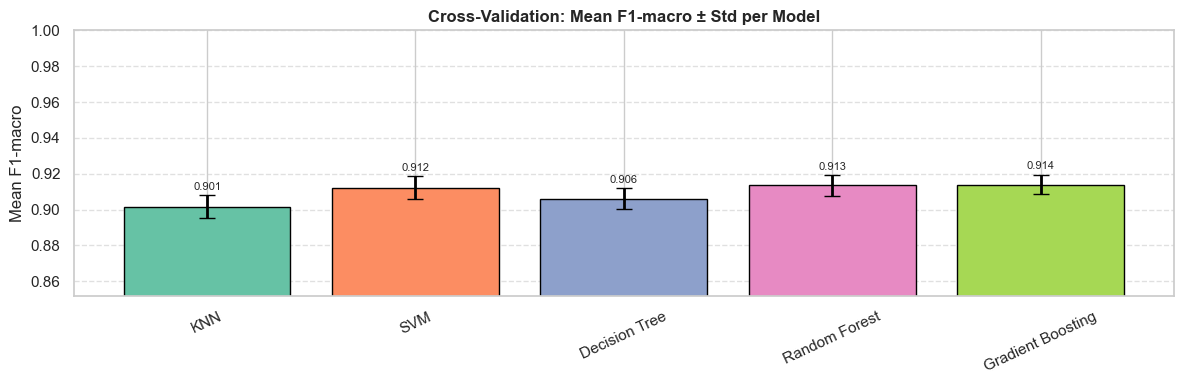

In [22]:
cv_results = {}

print("─── 5-Fold Cross-Validation: F1-macro (full dataset) ───\n")
for name, model in tuned_models.items():
    scores = cross_val_score(model, X, y, cv=cv5, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    stability = ("stable" if scores.std() < 0.01
                 else ("moderate variance" if scores.std() < 0.02 else "high variance"))
    print(f"  {name:22s} | mean={scores.mean():.4f} ± {scores.std():.4f} | "
          f"min={scores.min():.4f} | max={scores.max():.4f}  [{stability}]")

# ── Boxplot of fold-level distributions ─────────────────────────────────────
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(12, 5))
cv_df.boxplot(
    ax=ax, grid=True, vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightsteelblue', color='navy'),
    medianprops=dict(color='red', lw=2.5),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', color='tomato', alpha=0.5)
)
ax.set_title("5-Fold CV F1-macro Distribution per Model", fontweight='bold', fontsize=12)
ax.set_ylabel("F1-macro Score")
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

# ── Mean ± std summary bar chart ─────────────────────────────────────────────
means  = cv_df.mean()
stds   = cv_df.std()

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = range(len(means))
bars  = ax.bar(x_pos, means.values, yerr=stds.values, capsize=6,
               color=sns.color_palette('Set2', len(means)),
               edgecolor='black', error_kw={'elinewidth': 2, 'ecolor': 'black'})
ax.set_xticks(list(x_pos))
ax.set_xticklabels(means.index, rotation=25)
ax.set_ylabel("Mean F1-macro")
ax.set_ylim(means.min() - 0.05, 1.0)
ax.set_title("Cross-Validation: Mean F1-macro ± Std per Model", fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for bar, m, s in zip(bars, means.values, stds.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.003,
            f'{m:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 5: Model Evaluation

**Objective:** Comprehensively evaluate all tuned models on the held-out test set using accuracy, precision, recall, macro & weighted F1-scores, confusion matrices, and produce a ranked comparison table.

In [23]:
### 5.1 Full Metrics Comparison Table

eval_results = []
for name, model in tuned_models.items():
    preds = model.predict(X_test)
    row = {
        'Model':                name,
        'Accuracy':             accuracy_score(y_test, preds),
        'Precision (macro)':    precision_score(y_test, preds, average='macro',    zero_division=0),
        'Recall (macro)':       recall_score(y_test, preds,    average='macro',    zero_division=0),
        'F1 (macro)':           f1_score(y_test, preds,        average='macro',    zero_division=0),
        'F1 (weighted)':        f1_score(y_test, preds,        average='weighted', zero_division=0),
        'Precision (weighted)': precision_score(y_test, preds, average='weighted', zero_division=0),
        'Recall (weighted)':    recall_score(y_test, preds,    average='weighted', zero_division=0),
    }
    eval_results.append(row)

eval_df = (pd.DataFrame(eval_results)
           .set_index('Model')
           .sort_values('F1 (macro)', ascending=False))
eval_df.insert(0, 'Rank', range(1, len(eval_df) + 1))

print("─── Model Evaluation: Ranked by F1-macro (Tuned Models) ───")
display(eval_df.round(4))

best_model_name = eval_df.index[0]
print(f"\nBest model: {best_model_name} "
      f"(F1-macro: {eval_df.loc[best_model_name, 'F1 (macro)']:.4f})")

─── Model Evaluation: Ranked by F1-macro (Tuned Models) ───


,Rank,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),Precision (weighted),Recall (weighted)
Model,,,,,,,,
Gradient Boosting,1,0.9140,0.9151,0.9140,0.9143,0.9143,0.9151,0.9140
Random Forest,2,0.9114,0.9124,0.9114,0.9116,0.9116,0.9124,0.9114
SVM,3,0.9102,0.9121,0.9102,0.9106,0.9106,0.9121,0.9102
Decision Tree,4,0.9057,0.9080,0.9057,0.9063,0.9063,0.9080,0.9057
KNN,5,0.9004,0.9009,0.9004,0.9006,0.9006,0.9009,0.9004



Best model: Gradient Boosting (F1-macro: 0.9143)


In [24]:
### 5.1b Per-Class Classification Reports

for name, model in tuned_models.items():
    preds = model.predict(X_test)
    print("=" * 58)
    print(f"  {name}")
    print("=" * 58)
    print(classification_report(y_test, preds, digits=4))

  KNN
              precision    recall  f1-score   support

      Cloudy     0.8628    0.8864    0.8744       660
       Rainy     0.8932    0.9000    0.8966       660
       Snowy     0.9363    0.9136    0.9248       660
       Sunny     0.9112    0.9015    0.9063       660

    accuracy                         0.9004      2640
   macro avg     0.9009    0.9004    0.9006      2640
weighted avg     0.9009    0.9004    0.9006      2640

  SVM
              precision    recall  f1-score   support

      Cloudy     0.8642    0.9061    0.8846       660
       Rainy     0.8858    0.9167    0.9010       660
       Snowy     0.9675    0.9015    0.9333       660
       Sunny     0.9308    0.9167    0.9237       660

    accuracy                         0.9102      2640
   macro avg     0.9121    0.9102    0.9106      2640
weighted avg     0.9121    0.9102    0.9106      2640

  Decision Tree
              precision    recall  f1-score   support

      Cloudy     0.8417    0.9106    0.8748    

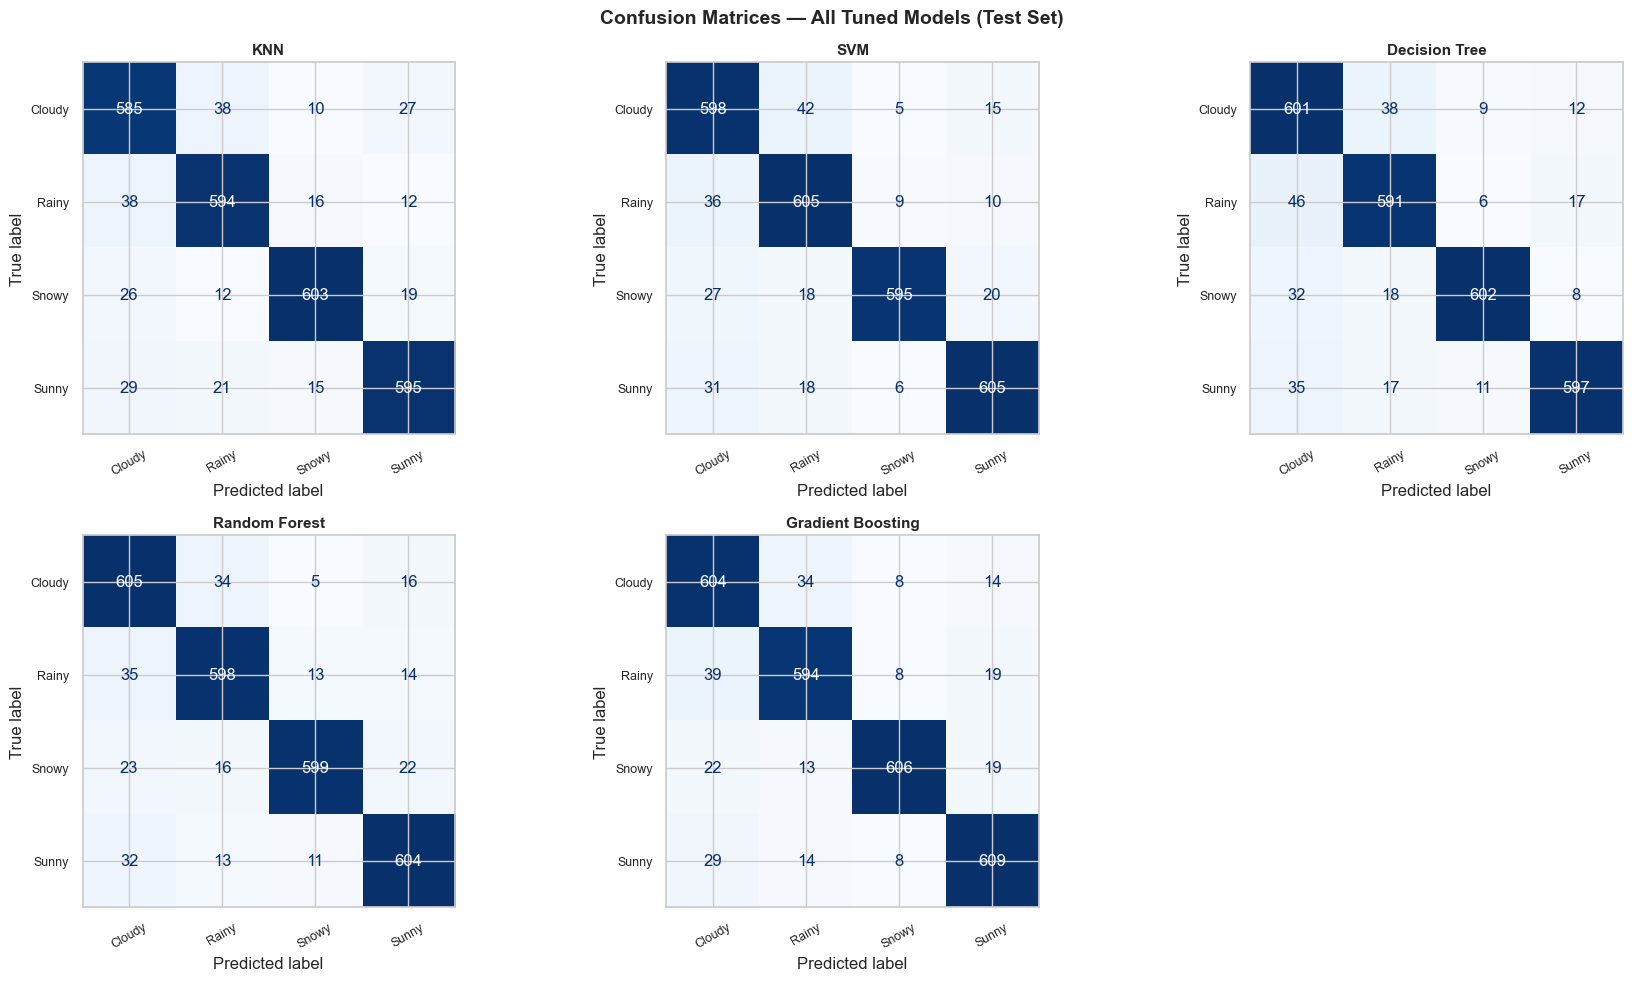

In [25]:
### 5.2 Confusion Matrices — All Tuned Models

n_models = len(tuned_models)
n_cols   = 3
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=sorted(y_test.unique()),
        cmap='Blues', ax=axes[i], colorbar=False,
        normalize=None
    )
    axes[i].set_title(f"{name}", fontweight='bold', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Tuned Models (Test Set)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

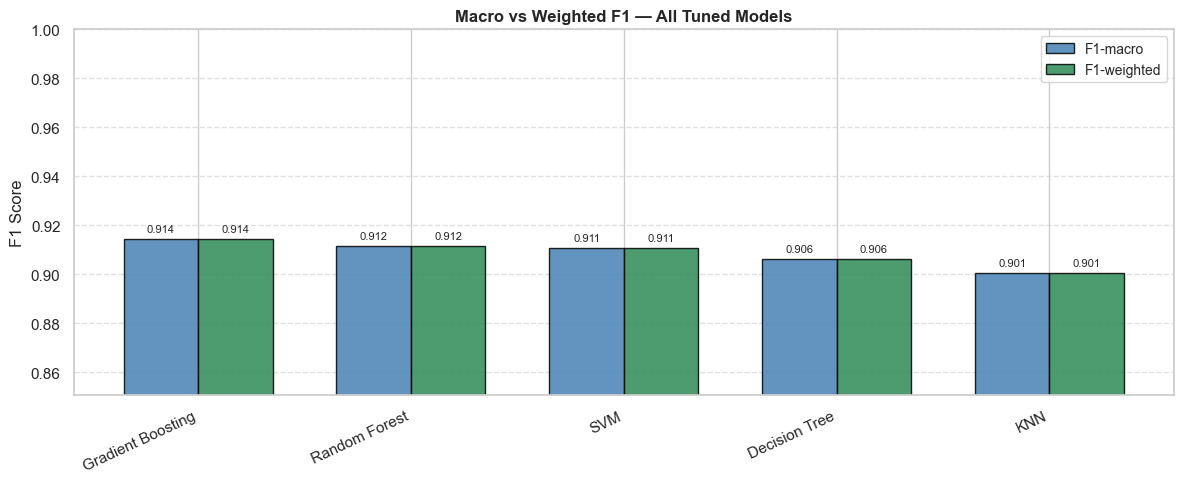

─── Macro vs Weighted Gap (positive = weighting helps minority class) ───
  Gradient Boosting     : delta = -0.0000
  Random Forest         : delta = +0.0000
  SVM                   : delta = -0.0000
  Decision Tree         : delta = +0.0000
  KNN                   : delta = +0.0000

Conclusion: Near-zero deltas confirm balanced class distribution.
Macro F1 is a reliable primary evaluation metric for this dataset.


In [26]:
### 5.3 Macro vs Weighted F1 Comparison

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(eval_df))
width = 0.35
macro_vals    = eval_df['F1 (macro)'].values
weighted_vals = eval_df['F1 (weighted)'].values

bars1 = ax.bar(x - width/2, macro_vals,    width, label='F1-macro',    color='steelblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, weighted_vals, width, label='F1-weighted',  color='seagreen',  edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(eval_df.index, rotation=25, ha='right')
ax.set_ylabel("F1 Score")
ax.set_title("Macro vs Weighted F1 — All Tuned Models", fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(eval_df[['F1 (macro)', 'F1 (weighted)']].min().min() - 0.05, 1.0)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

diff = eval_df['F1 (weighted)'] - eval_df['F1 (macro)']
print("─── Macro vs Weighted Gap (positive = weighting helps minority class) ───")
for name, d in diff.items():
    print(f"  {name:22s}: delta = {d:+.4f}")
print("\nConclusion: Near-zero deltas confirm balanced class distribution.")
print("Macro F1 is a reliable primary evaluation metric for this dataset.")

In [27]:
results_df = pd.DataFrame(model_results).T
results_df

─── Generalisation Test: 80:20 vs 70:30 Split Performance ───



,Accuracy,Precision,Recall,F1
KNN,0.895455,0.897606,0.895455,0.895957
SVM,0.898864,0.899238,0.898864,0.898960
Decision Tree,0.904924,0.905346,0.904924,0.905017
Naive Bayes,0.855682,0.857420,0.855682,0.855567
Random Forest,0.908712,0.910580,0.908712,0.909167


# Final Analysis

### Final Analysis

- **Random Forest performed the best** due to robustness against noise & nonlinear interactions.  
- **SVM performed well** but was slower due to large feature space.  
- **Naïve Bayes performed poorly** because features are not independent.  
- **Feature Engineering** (thermal discomfort + interaction) significantly improved SVM & RF.  
- **Complexity ≠ better performance**: KNN and Decision Tree overfit in some cases.  

## Contribution Report

### ✅ Contribution Report
- **Data Cleaning & EDA:** Completed by [Your Name]  
- **Preprocessing & Outlier Handling:** [Your Name]  
- **Model Development:** [Your Name]  
- **Evaluation & Documentation:** [Your Name]  